[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/subramanyanaik/schoolofai_subbu/blob/main/assignment11/optimizer_harness.ipynb)

Generated from [`optimizer_harness.py`](optimizer_harness.py) by `tools/build_notebook.py` - edit the `.py`, not this file.

# Session 11 — Reproduce the optimizer, then refuse to believe any comparison you did not tune

Adam is four lines of arithmetic wrapped around two exponential moving averages, and every
training run in this course is steered by it. This notebook takes it apart by hand and then
uses it to answer five questions that only a measurement can settle:

1. **Adam by hand.** One weight, five gradients, `m`, `v`, `m̂`, `v̂` and the resulting step
   computed in plain Python, then checked against `torch.optim.Adam` — state included, not
   just the weight.
2. **Bias correction off.** The first twenty steps plotted both ways, and an answer to
   "after how many steps does the difference stop mattering" that is explicit about which
   of three defensible criteria it is answering.
3. **Update-to-weight ratio, every layer, every step**, and the step at which warmup stops
   being the thing that changes it — measured against a no-warmup run rather than read off
   the schedule.
4. **Cosine vs WSD**, both tuned, both trained for 300 steps, both stopped at 200 — and a
   third arm, because "stop both at 200" is a question about *budget*, and WSD's whole claim
   is that it answers that question differently.
5. **A learning-rate sweep at widths 256, 512 and 1024**, in both standard parameterisation
   and μP, three minima marked, and a value for width 4096 with a stated confidence — tested
   at a held-out width rather than asserted.
6. **Tune both sides.** The same two optimizers compared twice: once the way that produces a
   publishable-looking result, once the way that produces a true one.

The instruction that governs all six: *tune both sides before accepting a comparison.*
Section 6 exists because it is easy to agree with that sentence and still not do it.

This file is the single source of truth. `tools/build_notebook.py` turns it, cell for cell,
into `optimizer_harness.ipynb`, and CI fails if the two drift apart. Every number quoted in
`README.md` is read out of `results/results.json`, which this run writes.

In [1]:
# ---------------------------------------------------------------------------------------
# Setup.  torch, numpy, matplotlib; everything else is stdlib.
# ---------------------------------------------------------------------------------------
import json
import math
import os
import sys
import time
import urllib.request

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib

IN_NOTEBOOK = "ipykernel" in sys.modules
if not IN_NOTEBOOK:                       # headless script run
    matplotlib.use("Agg")
import matplotlib.pyplot as plt


def show(fig):
    """Display inline in a notebook; close silently in a headless script run."""
    if IN_NOTEBOOK:
        plt.show()
    else:
        plt.close(fig)


RESULTS = {}          # every number the write-up quotes ends up in here

try:                                      # running as a script
    HERE = os.path.dirname(os.path.abspath(__file__))
except NameError:                         # running as a notebook
    HERE = os.getcwd()
OUT_DIR = os.path.join(HERE, "results")
os.makedirs(OUT_DIR, exist_ok=True)

T_START = time.time()
if not IN_NOTEBOOK:                       # so a redirected log is UTF-8, not cp1252
    try:
        sys.stdout.reconfigure(encoding="utf-8")
    except Exception:
        pass


def rule(title):
    el = time.time() - T_START
    print("\n" + "=" * 92)
    print(f"{title}   [t+{int(el) // 60:d}m{int(el) % 60:02d}s]")
    print("=" * 92)


def record(key, value):
    RESULTS[key] = value
    return value


SEED = 1337
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(SEED)
np.random.seed(SEED)

rule("Environment")
print(f"python        : {sys.version.split()[0]}")
print(f"torch         : {torch.__version__}")
print(f"device        : {device}")
if device.type == "cuda":
    props = torch.cuda.get_device_properties(0)
    print(f"gpu           : {props.name}  ({props.total_memory / 2**30:.2f} GiB, "
          f"{props.multi_processor_count} SMs, sm_{props.major}{props.minor})")
    record("gpu", props.name)
    record("gpu_total_gib", round(props.total_memory / 2**30, 2))
    record("gpu_sms", props.multi_processor_count)
    record("gpu_cc", f"{props.major}.{props.minor}")
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True
else:
    record("gpu", None)
record("torch_version", torch.__version__)
record("seed", SEED)


def digits_agreeing(a, b):
    """Significant decimal digits two numbers share; 16 means 'to the limit of float64'."""
    a, b = float(a), float(b)
    if a == b:
        return 16.0
    scale = max(abs(a), abs(b))
    if scale == 0:
        return 16.0
    return max(0.0, -math.log10(abs(a - b) / scale))


Environment   [t+0m01s]
python        : 3.12.6
torch         : 2.5.1+cu121
device        : cuda
gpu           : NVIDIA GeForce RTX 3050 Laptop GPU  (4.00 GiB, 16 SMs, sm_86)


## 1. Adam by hand

One weight. Five gradients. Everything in float64, in plain Python, with no tensor
anywhere — because the point of the exercise is that if you cannot write the four lines
down, you do not know what the optimizer is doing to your model.

$$m_t = \beta_1 m_{t-1} + (1-\beta_1) g_t \qquad v_t = \beta_2 v_{t-1} + (1-\beta_2) g_t^2$$

$$\hat m_t = \frac{m_t}{1-\beta_1^t} \qquad \hat v_t = \frac{v_t}{1-\beta_2^t} \qquad
  w_t = w_{t-1} - \eta \frac{\hat m_t}{\sqrt{\hat v_t} + \epsilon}$$

`m` is the direction — the exponential moving average of the gradient, which is momentum,
and which is what stops a parameter from oscillating across a valley. `v` is the scale —
the same average over the *squared* gradient, which is the per-parameter learning rate the
lecture spent an hour arriving at. The hat terms exist because both averages start at zero
and are therefore biased toward zero for as long as that zero is still inside the window;
section 2 is entirely about them.

The gradients below are chosen to exercise the machinery rather than to look tidy: a sign
flip at step 3 (does momentum survive it?) and a 30× outlier at step 4 (does the step size
survive *that*?).

In [2]:
rule("1. Adam by hand -- five steps, in plain Python")

W0 = 0.35
GRADS = [0.10, 0.20, -0.05, 1.50, 0.08]
LR, B1, B2, EPS = 1e-3, 0.9, 0.999, 1e-8


def adam_by_hand(w0, grads, lr=LR, b1=B1, b2=B2, eps=EPS, bias_correction=True):
    """Adam, written out.  Returns one row per step with every intermediate value."""
    w, m, v, rows = float(w0), 0.0, 0.0, []
    for t, g in enumerate(grads, start=1):
        m = b1 * m + (1.0 - b1) * g
        v = b2 * v + (1.0 - b2) * g * g
        if bias_correction:
            mhat = m / (1.0 - b1 ** t)
            vhat = v / (1.0 - b2 ** t)
        else:
            mhat, vhat = m, v
        step = lr * mhat / (math.sqrt(vhat) + eps)
        w_new = w - step
        rows.append(dict(t=t, g=g, m=m, v=v, mhat=mhat, vhat=vhat,
                         denom=math.sqrt(vhat) + eps, step=step, w=w_new))
        w = w_new
    return rows


hand = adam_by_hand(W0, GRADS)

print(f"w0 = {W0}   lr = {LR}   betas = ({B1}, {B2})   eps = {EPS}\n")
hdr = (f"{'t':>2} {'g':>8} {'m':>13} {'v':>14} {'m_hat':>13} {'v_hat':>14} "
       f"{'step':>14} {'w':>16}")
print(hdr)
print("-" * len(hdr))
for r in hand:
    print(f"{r['t']:>2} {r['g']:>8.2f} {r['m']:>13.9f} {r['v']:>14.10f} "
          f"{r['mhat']:>13.9f} {r['vhat']:>14.10f} {r['step']:>14.10f} {r['w']:>16.12f}")

record("hand_w0", W0)
record("hand_grads", GRADS)
record("hand_lr", LR)
record("hand_b1", B1)
record("hand_b2", B2)
record("hand_eps", EPS)
record("hand_rows", [{k: float(v) for k, v in r.items()} for r in hand])
record("hand_w_final", hand[-1]["w"])


1. Adam by hand -- five steps, in plain Python   [t+0m01s]
w0 = 0.35   lr = 0.001   betas = (0.9, 0.999)   eps = 1e-08

 t        g             m              v         m_hat          v_hat           step                w
-----------------------------------------------------------------------------------------------------
 1     0.10   0.010000000   0.0000100000   0.100000000   0.0100000000   0.0009999999   0.349000000100
 2     0.20   0.029000000   0.0000499900   0.152631579   0.0250075038   0.0009651820   0.348034818135
 3    -0.05   0.021100000   0.0000524400   0.077859779   0.0174974950   0.0005886067   0.347446211447
 4     1.50   0.168990000   0.0023023876   0.491392847   0.5764610077   0.0006472080   0.346799003478
 5     0.08   0.160091000   0.0023064852   0.390933066   0.4622205536   0.0005750131   0.346223990333


0.3462239903329248

### The same five steps, through `torch.optim.Adam`

A one-element parameter, float64 on the CPU, with the gradient *assigned* rather than
computed — so the only thing under test is the optimizer. Torch does not store `m̂` and
`v̂` anywhere (it folds both corrections into the step, in a different algebraic order than
the paper writes them), so the comparison is made against the two things it does store,
`exp_avg` and `exp_avg_sq`, plus the weight after each step.

In [3]:
p = torch.tensor([W0], dtype=torch.float64, requires_grad=True)
opt = torch.optim.Adam([p], lr=LR, betas=(B1, B2), eps=EPS)

torch_rows = []
for g in GRADS:
    p.grad = torch.tensor([g], dtype=torch.float64)
    opt.step()
    st = opt.state[p]
    torch_rows.append(dict(m=st["exp_avg"].item(), v=st["exp_avg_sq"].item(),
                           w=p.item(), t=float(st["step"])))

print(f"{'t':>2}  {'quantity':<8} {'by hand':>22} {'torch':>22} {'abs diff':>11} {'digits':>7}")
print("-" * 78)

worst = 1e9
for h, tr in zip(hand, torch_rows):
    for name, hv, tv in (("m", h["m"], tr["m"]), ("v", h["v"], tr["v"]),
                         ("w", h["w"], tr["w"])):
        d = digits_agreeing(hv, tv)
        worst = min(worst, d)
        print(f"{h['t']:>2}  {name:<8} {hv:>22.16f} {tv:>22.16f} "
              f"{abs(hv - tv):>11.2e} {d:>7.1f}")
    print("-" * 78)

maxdiff_w = max(abs(h["w"] - tr["w"]) for h, tr in zip(hand, torch_rows))
print(f"\nlargest disagreement on the weight over five steps : {maxdiff_w:.3e}")
print(f"worst agreement across m, v and w, in digits       : {worst:.1f}")
print(f"final weight   by hand : {hand[-1]['w']:.16f}")
print(f"final weight   torch   : {torch_rows[-1]['w']:.16f}")
record("torch_rows", [{k: float(v) for k, v in r.items()} for r in torch_rows])
record("hand_vs_torch_maxdiff_w", maxdiff_w)
record("hand_vs_torch_worst_digits", round(worst, 1))
record("hand_vs_torch_final_w_torch", torch_rows[-1]["w"])

 t  quantity                by hand                  torch    abs diff  digits
------------------------------------------------------------------------------
 1  m            0.0100000000000000     0.0100000000000000    0.00e+00    16.0
 1  v            0.0000100000000000     0.0000100000000000    0.00e+00    16.0
 1  w            0.3490000001000000     0.3490000001000000    0.00e+00    16.0
------------------------------------------------------------------------------
 2  m            0.0290000000000000     0.0290000000000000    3.47e-18    15.9
 2  v            0.0000499900000000     0.0000499900000000    0.00e+00    16.0
 2  w            0.3480348181352125     0.3480348181352125    0.00e+00    16.0
------------------------------------------------------------------------------
 3  m            0.0211000000000000     0.0211000000000000    6.94e-18    15.5
 3  v            0.0000524400100000     0.0000524400100000    0.00e+00    16.0
 3  w            0.3474462114469811     0.3474462114

0.3462239903329248

### Three things the table says that the formula does not

Reading five rows of arithmetic is worth more than reading the update rule, because the
rows show the behaviour the rule only implies.

In [4]:
rule("1b. What the five rows actually show")

# (a) the first step is exactly lr, whatever the gradient is.
first_step_over_lr = abs(hand[0]["step"]) / LR
print(f"|step 1| / lr                       : {first_step_over_lr:.10f}")
print(f"   at t=1, m_hat = g and v_hat = g^2, so the step is lr * g/|g| -- the gradient's")
print(f"   *size* cancels exactly, and only its sign survives.")

# (b) the 30x outlier at t=4 does not produce a 30x step.
g_ratio = abs(GRADS[3]) / abs(GRADS[2])
step_ratio = abs(hand[3]["step"]) / abs(hand[2]["step"])
print(f"\ngradient at t=4 vs t=3              : {g_ratio:.1f}x")
print(f"step     at t=4 vs t=3              : {step_ratio:.2f}x")
print(f"   a {g_ratio:.0f}x gradient bought a {step_ratio:.2f}x step.  That ratio is the "
      f"whole reason Adam is used")
print(f"   on language models: v cancels the scale of g, so a parameter that only ever sees")
print(f"   tiny gradients still moves, and one that sees a spike does not explode.")

# (c) and the cost of it: after the spike, v stays large, so the next step is small.
print(f"\nstep at t=5 (g = 0.08)              : {hand[4]['step']:.3e}")
print(f"step at t=2 (g = 0.20, same order)  : {hand[1]['step']:.3e}")
print(f"   the spike is still in v at t=5, shrinking every subsequent step until it decays")
print(f"   out of the window -- about 1/(1-b2) = {1 / (1 - B2):.0f} steps.")

record("first_step_over_lr", first_step_over_lr)
record("outlier_g_ratio", g_ratio)
record("outlier_step_ratio", step_ratio)
record("v_window", int(round(1 / (1 - B2))))


1b. What the five rows actually show   [t+0m02s]
|step 1| / lr                       : 0.9999999000
   at t=1, m_hat = g and v_hat = g^2, so the step is lr * g/|g| -- the gradient's
   *size* cancels exactly, and only its sign survives.

gradient at t=4 vs t=3              : 30.0x
step     at t=4 vs t=3              : 1.10x
   a 30x gradient bought a 1.10x step.  That ratio is the whole reason Adam is used
   on language models: v cancels the scale of g, so a parameter that only ever sees
   tiny gradients still moves, and one that sees a spike does not explode.

step at t=5 (g = 0.08)              : 5.750e-04
step at t=2 (g = 0.20, same order)  : 9.652e-04
   the spike is still in v at t=5, shrinking every subsequent step until it decays
   out of the window -- about 1/(1-b2) = 1000 steps.


1000

### The claim that makes Adam what it is, tested

`v` is supposed to cancel the *scale* of the gradient entirely: multiply every gradient in
the run by 1000 and the weight trajectory should not move. It is not exactly true — `eps`
breaks it, deliberately — and measuring by how much is more informative than believing it.

In [5]:
scaled = adam_by_hand(W0, [g * 1000.0 for g in GRADS])
tiny = adam_by_hand(W0, [g * 1e-6 for g in GRADS])

drift_up = max(abs(a["w"] - b["w"]) for a, b in zip(hand, scaled))
drift_dn = max(abs(a["w"] - b["w"]) for a, b in zip(hand, tiny))
dig_up = digits_agreeing(hand[-1]["w"], scaled[-1]["w"])
dig_dn = digits_agreeing(hand[-1]["w"], tiny[-1]["w"])
print(f"gradients x1000,  largest weight difference : {drift_up:.3e}  "
      f"({dig_up:.0f} digits identical)")
print(f"gradients x1e-6,  largest weight difference : {drift_dn:.3e}  "
      f"({dig_dn:.0f} digits identical)")
print(f"   eps = {EPS:.0e} sits in the denominator next to sqrt(v_hat).  When the gradients "
      f"are small")
print(f"   enough that sqrt(v_hat) approaches eps, the scale stops cancelling and Adam "
      f"degenerates")
print(f"   toward plain SGD.  That is the failure mode eps is usually described as "
      f"preventing, and")
print(f"   it is also the one it causes -- which is why eps is a hyperparameter and not a "
      f"constant.")
record("scale_inv_drift_up", drift_up)
record("scale_inv_drift_dn", drift_dn)
record("scale_inv_digits_up", round(dig_up, 1))
record("scale_inv_digits_dn", round(dig_dn, 1))

gradients x1000,  largest weight difference : 2.223e-10  (9 digits identical)
gradients x1e-6,  largest weight difference : 2.064e-04  (3 digits identical)
   eps = 1e-08 sits in the denominator next to sqrt(v_hat).  When the gradients are small
   enough that sqrt(v_hat) approaches eps, the scale stops cancelling and Adam degenerates
   toward plain SGD.  That is the failure mode eps is usually described as preventing, and
   it is also the one it causes -- which is why eps is a hyperparameter and not a constant.


3.2

### Adam + L2 is not AdamW, and five steps is enough to see it

The lecture's weight-decay section, made concrete. `Adam(weight_decay=λ)` adds `λw` to the
**gradient**, so the decay flows through `m` and `v` and gets divided by `√v̂` along with
everything else — a parameter with large gradients is decayed *less*, which is the opposite
of what a regulariser is for. `AdamW` subtracts `ηλw` from the weight directly, after the
Adam step, untouched by either moment. Same λ, same five gradients, different answers.

In [6]:
LAM = 0.1                                  # exaggerated so five steps suffice to show it


def adam_l2(w0, grads, lam, lr=LR, b1=B1, b2=B2, eps=EPS):
    """Coupled L2: the decay enters through the gradient, so v rescales it."""
    w, m, v = float(w0), 0.0, 0.0
    for t, g in enumerate(grads, start=1):
        g = g + lam * w
        m = b1 * m + (1 - b1) * g
        v = b2 * v + (1 - b2) * g * g
        w -= lr * (m / (1 - b1 ** t)) / (math.sqrt(v / (1 - b2 ** t)) + eps)
    return w


def adamw_by_hand(w0, grads, lam, lr=LR, b1=B1, b2=B2, eps=EPS, decay_first=True):
    """Decoupled: the decay is applied to the weight itself, untouched by m or v.

    `decay_first` is not cosmetic.  Loshchilov & Hutter's Algorithm 2 subtracts the Adam step
    and the decay from the same w; torch shrinks w *before* taking the Adam step.  Both are
    'decoupled'; they are not the same number."""
    w, m, v = float(w0), 0.0, 0.0
    for t, g in enumerate(grads, start=1):
        m = b1 * m + (1 - b1) * g
        v = b2 * v + (1 - b2) * g * g
        if decay_first:
            w *= (1 - lr * lam)
            w -= lr * (m / (1 - b1 ** t)) / (math.sqrt(v / (1 - b2 ** t)) + eps)
        else:
            w -= lr * (m / (1 - b1 ** t)) / (math.sqrt(v / (1 - b2 ** t)) + eps)
            w -= lr * lam * w
    return w


w_l2 = adam_l2(W0, GRADS, LAM)
w_adw = adamw_by_hand(W0, GRADS, LAM)
w_adw_last = adamw_by_hand(W0, GRADS, LAM, decay_first=False)

pa = torch.tensor([W0], dtype=torch.float64, requires_grad=True)
oa = torch.optim.Adam([pa], lr=LR, betas=(B1, B2), eps=EPS, weight_decay=LAM)
pw = torch.tensor([W0], dtype=torch.float64, requires_grad=True)
ow = torch.optim.AdamW([pw], lr=LR, betas=(B1, B2), eps=EPS, weight_decay=LAM)
for g in GRADS:
    pa.grad = torch.tensor([g], dtype=torch.float64)
    oa.step()
    pw.grad = torch.tensor([g], dtype=torch.float64)
    ow.step()

print(f"{'':<34}{'by hand':>20}{'torch':>20}{'digits':>9}")
print(f"{'Adam + L2 (decay in the gradient)':<34}{w_l2:>20.16f}{pa.item():>20.16f}"
      f"{digits_agreeing(w_l2, pa.item()):>9.1f}")
print(f"{'AdamW (decoupled)':<34}{w_adw:>20.16f}{pw.item():>20.16f}"
      f"{digits_agreeing(w_adw, pw.item()):>9.1f}")
print(f"{'no decay at all':<34}{hand[-1]['w']:>20.16f}")
print(f"\nthe two decay rules differ by {abs(w_l2 - w_adw):.3e} after five steps at "
      f"lambda={LAM}, and both")
print(f"reproduce torch to "
      f"{min(digits_agreeing(w_l2, pa.item()), digits_agreeing(w_adw, pw.item())):.0f} "
      f"digits -- so the difference is the algorithm, not the arithmetic.")
print(f"\nand a detail found only by insisting on all 16 digits: torch shrinks w *before*")
print(f"taking the Adam step, while the AdamW paper's Algorithm 2 subtracts both from the")
print(f"same w.  Decaying last instead gives {w_adw_last:.16f}, which differs by")
print(f"{abs(w_adw - w_adw_last):.2e} -- O(eta^2 lambda) per step, invisible at four decimal")
print(f"places and the reason a 'reimplementation of AdamW' can be subtly not AdamW.")
record("wd_lambda", LAM)
record("wd_adam_l2_hand", w_l2)
record("wd_adamw_hand", w_adw)
record("wd_adamw_decay_last", w_adw_last)
record("wd_order_gap", abs(w_adw - w_adw_last))
record("wd_adam_l2_digits", round(digits_agreeing(w_l2, pa.item()), 1))
record("wd_adamw_digits", round(digits_agreeing(w_adw, pw.item()), 1))
record("wd_gap", abs(w_l2 - w_adw))

                                               by hand               torch   digits
Adam + L2 (decay in the gradient)   0.3460175049080650  0.3460175049080650     16.0
AdamW (decoupled)                   0.3460498972312724  0.3460498972312724     16.0
no decay at all                     0.3462239903329248

the two decay rules differ by 3.239e-05 after five steps at lambda=0.1, and both
reproduce torch to 16 digits -- so the difference is the algorithm, not the arithmetic.

and a detail found only by insisting on all 16 digits: torch shrinks w *before*
taking the Adam step, while the AdamW paper's Algorithm 2 subtracts both from the
same w.  Decaying last instead gives 0.3460502747450490, which differs by
3.78e-07 -- O(eta^2 lambda) per step, invisible at four decimal
places and the reason a 'reimplementation of AdamW' can be subtly not AdamW.


3.239232320734198e-05

## 0. The model, the data, and one optimizer written from scratch

Sections 2 to 6 need a real model, and they need to run it dozens of times. The choices
below are made to keep the *optimizer* the only interesting variable:

* **Character-level Tiny Shakespeare, `V = 65`.** A 50,257-entry vocabulary would make the
  output head 80% of the parameters at width 256 and 20% at width 1024, so a "width sweep"
  would really be a sweep over how much of the model is the head. At `V = 65` the width
  sweep is about width.
* **Head dimension fixed at 64, heads grow with width** (4, 8, 16, 32) — which is what real
  scaling does, and which means the `1/√d_head` attention scale needs no μP correction.
* **`wte` and `lm_head` are untied**, in both parameterisations, because μP gives the input
  and output layers different learning rates and tying them would make that impossible.
* **No biases**, so every parameter is either a matrix, an embedding, or a LayerNorm gain,
  which is exactly the three-way split μP cares about.

And one optimizer written from scratch, because section 2 has to be able to *switch bias
correction off* — which `torch.optim` will not let you do. It is checked against
`torch.optim.AdamW` twice a few cells below, before anything depends on it, and the two
checks disagree in a way that turns out to set the resolution of the whole notebook.

In [7]:
# ---------------------------------------------------------------------------------------
# Data.  Tiny Shakespeare, character level.
# ---------------------------------------------------------------------------------------
DATA_URL = ("https://raw.githubusercontent.com/karpathy/char-rnn/master/data/"
            "tinyshakespeare/input.txt")
DATA_PATH = os.path.join(OUT_DIR, "tinyshakespeare.txt")
if not os.path.exists(DATA_PATH):
    with urllib.request.urlopen(DATA_URL, timeout=60) as r:
        open(DATA_PATH, "wb").write(r.read())

text = open(DATA_PATH, "r", encoding="utf-8").read()
CHARS = sorted(set(text))
VOCAB_SIZE = len(CHARS)
stoi = {c: i for i, c in enumerate(CHARS)}
ids = torch.tensor([stoi[c] for c in text], dtype=torch.int64)
n_train = int(0.9 * len(ids))
train_ids, val_ids = ids[:n_train], ids[n_train:]

B, T = 16, 128                             # every run in this notebook uses these
BASE_WIDTH = 256                           # muP's base width; also the default width
N_LAYER = 2
HEAD_DIM = 64

rule("Data and shapes")
print(f"characters      : {len(text):,}")
print(f"vocabulary      : {VOCAB_SIZE} distinct characters")
print(f"train / val     : {len(train_ids):,} / {len(val_ids):,} tokens")
print(f"batch           : B={B}, T={T}  ->  {B * T:,} tokens per step")
record("vocab_size", VOCAB_SIZE)
record("train_tokens", int(len(train_ids)))
record("val_tokens", int(len(val_ids)))
record("B", B)
record("T", T)
record("base_width", BASE_WIDTH)
record("n_layer", N_LAYER)
record("head_dim", HEAD_DIM)
record("uniform_loss", math.log(VOCAB_SIZE))


def get_batch(data, gen, dev=None):
    ix = torch.randint(len(data) - T - 1, (B,), generator=gen)
    x = torch.stack([data[i:i + T] for i in ix])
    y = torch.stack([data[i + 1:i + 1 + T] for i in ix])
    dev = dev or device
    return x.to(dev, non_blocking=True), y.to(dev, non_blocking=True)


# A fixed evaluation set, built once, identical for every run in the notebook.  Every loss
# quoted below is measured on exactly these batches, so no two runs are judged by different
# rulers.
_eval_gen = torch.Generator().manual_seed(20250911)
EVAL_BATCHES = [get_batch(val_ids, _eval_gen, dev="cpu") for _ in range(16)]
print(f"held-out ruler  : {len(EVAL_BATCHES)} fixed val batches "
      f"= {len(EVAL_BATCHES) * B * T:,} tokens")
record("n_eval_batches", len(EVAL_BATCHES))


Data and shapes   [t+0m03s]
characters      : 1,115,394
vocabulary      : 65 distinct characters
train / val     : 1,003,854 / 111,540 tokens
batch           : B=16, T=128  ->  2,048 tokens per step
held-out ruler  : 16 fixed val batches = 32,768 tokens


16

In [8]:
# ---------------------------------------------------------------------------------------
# The model.  nanoGPT's block, biases removed, head dim fixed so heads grow with width.
# ---------------------------------------------------------------------------------------
class Block(nn.Module):
    def __init__(self, width):
        super().__init__()
        self.n_head = width // HEAD_DIM
        self.ln1 = nn.LayerNorm(width)
        self.ln2 = nn.LayerNorm(width)
        self.attn = nn.Linear(width, 3 * width, bias=False)
        self.attn_proj = nn.Linear(width, width, bias=False)
        self.fc = nn.Linear(width, 4 * width, bias=False)
        self.fc_proj = nn.Linear(4 * width, width, bias=False)

    def forward(self, x):
        Bq, Tq, C = x.shape
        q, k, v = self.attn(self.ln1(x)).split(C, dim=2)
        q = q.view(Bq, Tq, self.n_head, HEAD_DIM).transpose(1, 2)
        k = k.view(Bq, Tq, self.n_head, HEAD_DIM).transpose(1, 2)
        v = v.view(Bq, Tq, self.n_head, HEAD_DIM).transpose(1, 2)
        y = F.scaled_dot_product_attention(q, k, v, is_causal=True)
        x = x + self.attn_proj(y.transpose(1, 2).contiguous().view(Bq, Tq, C))
        x = x + self.fc_proj(F.gelu(self.fc(self.ln2(x))))
        return x


class GPT(nn.Module):
    """`parameterization` is 'sp' (nanoGPT's: every weight init 0.02, one global lr) or
    'mup' (hidden and readout weights init 0.02/sqrt(m) and given lr/m, where m is the
    width multiple over BASE_WIDTH; embeddings and LayerNorm gains are left alone)."""

    def __init__(self, width, parameterization="sp", n_layer=N_LAYER, seed=SEED):
        super().__init__()
        torch.manual_seed(seed)
        self.width, self.parameterization, self.n_layer = width, parameterization, n_layer
        self.mult = width / BASE_WIDTH
        self.wte = nn.Embedding(VOCAB_SIZE, width)
        self.wpe = nn.Embedding(T, width)
        self.h = nn.ModuleList([Block(width) for _ in range(n_layer)])
        self.ln_f = nn.LayerNorm(width)
        self.lm_head = nn.Linear(width, VOCAB_SIZE, bias=False)
        self._init()

    def _init(self):
        # sqrt(m) for muP on everything whose fan-in grows with width; 1 for SP.
        shrink = math.sqrt(self.mult) if self.parameterization == "mup" else 1.0
        for name, par in self.named_parameters():
            if name.startswith(("wte", "wpe")):            # input-like: never rescaled
                nn.init.normal_(par, 0.0, 0.02)
            elif par.ndim >= 2:                            # hidden and readout matrices
                std = 0.02 / shrink
                if name.endswith("_proj.weight"):          # nanoGPT's residual scaling
                    std /= math.sqrt(2 * self.n_layer)
                nn.init.normal_(par, 0.0, std)
            # LayerNorm gains keep torch's default (ones / zeros)

    def groups(self):
        """The three kinds of parameter muP distinguishes, as (name, params) pairs."""
        embed, matrix, vector = [], [], []
        for name, par in self.named_parameters():
            if name.startswith(("wte", "wpe")):
                embed.append((name, par))
            elif par.ndim >= 2:
                matrix.append((name, par))
            else:
                vector.append((name, par))
        return dict(embedding=embed, matrix=matrix, vector=vector)

    def forward(self, idx, targets, want_acts=False):
        Bq, Tq = idx.shape
        x = self.wte(idx) + self.wpe(torch.arange(Tq, device=idx.device))
        for blk in self.h:
            x = blk(x)
        h = self.ln_f(x)
        logits = self.lm_head(h)
        loss = F.cross_entropy(logits.view(-1, logits.size(-1)), targets.reshape(-1))
        if want_acts:
            return loss, dict(resid=x.detach().float().pow(2).mean().sqrt().item(),
                              logits=logits.detach().float().pow(2).mean().sqrt().item())
        return loss, None


def lr_groups(model, lr, parameterization):
    """muP's learning rate per group.  Matrix-like parameters (hidden and readout) get
    lr / m; embeddings and LayerNorm gains keep lr.  SP gives everything lr."""
    g = model.groups()
    scale = model.mult if parameterization == "mup" else 1.0
    return [
        dict(params=[p for _, p in g["embedding"]], lr=lr, tag="embedding"),
        dict(params=[p for _, p in g["matrix"]], lr=lr / scale, tag="matrix"),
        dict(params=[p for _, p in g["vector"]], lr=lr, tag="vector"),
    ]

In [9]:
# ---------------------------------------------------------------------------------------
# AdamW, written out, with a switch section 2 needs and torch.optim does not have.
# ---------------------------------------------------------------------------------------
class HandAdamW(torch.optim.Optimizer):
    """The same four lines as section 1, applied elementwise, with decoupled weight decay.

    `bias_correction=False` drops the two hat terms and nothing else, which is exactly the
    ablation section 2 asks for."""

    def __init__(self, params, lr=1e-3, betas=(0.9, 0.999), eps=1e-8, weight_decay=0.0,
                 bias_correction=True, counterfactual=False):
        super().__init__(params, dict(lr=lr, betas=betas, eps=eps,
                                      weight_decay=weight_decay,
                                      bias_correction=bias_correction))
        # When on, each step also computes the update the *other* setting of
        # bias_correction would have produced from the same m and v -- which isolates the
        # correction from the fact that two separate runs stop sharing a trajectory.
        self.counterfactual = counterfactual
        self.taken_sq = self.other_sq = self.n_el = 0.0

    @torch.no_grad()
    def step(self, closure=None):
        self.taken_sq = self.other_sq = self.n_el = 0.0
        for group in self.param_groups:
            b1, b2 = group["betas"]
            lr, eps, wd = group["lr"], group["eps"], group["weight_decay"]
            bc = group["bias_correction"]
            for par in group["params"]:
                if par.grad is None:
                    continue
                g = par.grad
                st = self.state[par]
                if not st:
                    st["t"] = 0
                    st["m"] = torch.zeros_like(par)
                    st["v"] = torch.zeros_like(par)
                st["t"] += 1
                t, m, v = st["t"], st["m"], st["v"]
                m.mul_(b1).add_(g, alpha=1 - b1)
                v.mul_(b2).addcmul_(g, g, value=1 - b2)
                if bc:
                    mhat = m / (1 - b1 ** t)
                    vhat = v / (1 - b2 ** t)
                else:
                    mhat, vhat = m, v
                if self.counterfactual:
                    om, ov = (m, v) if bc else (m / (1 - b1 ** t), v / (1 - b2 ** t))
                    self.taken_sq += (mhat / (vhat.sqrt() + eps)).pow_(2).sum().item()
                    self.other_sq += (om / (ov.sqrt() + eps)).pow_(2).sum().item()
                    self.n_el += par.numel()
                if wd:
                    par.mul_(1 - lr * wd)
                par.addcdiv_(mhat, vhat.sqrt().add_(eps), value=-lr)


def lr_at(step, total, lr_max, schedule, warmup, decay_frac=0.2, lr_min_frac=0.1):
    """The schedules the lecture drew: warmup, then cosine to lr_min, or warmup, then a
    long constant stretch, then a short linear cooldown (WSD)."""
    lr_min = lr_max * lr_min_frac
    if warmup > 0 and step < warmup:
        return lr_max * (step + 1) / warmup
    if schedule == "constant":
        return lr_max
    # total - 1 - x, not total - x: the last step of a `total`-step run is `total - 1`, and
    # a cooldown that only reaches lr_min one step after the run ends has not cooled down.
    if schedule == "cosine":
        prog = (step - warmup) / max(1, total - 1 - warmup)
        return lr_min + 0.5 * (lr_max - lr_min) * (1 + math.cos(math.pi * min(1.0, prog)))
    if schedule == "wsd":
        decay_start = total - int(round(decay_frac * total))
        if step < decay_start:
            return lr_max
        prog = (step - decay_start) / max(1, total - 1 - decay_start)
        return lr_max + (lr_min - lr_max) * min(1.0, prog)
    raise ValueError(schedule)


@torch.no_grad()
def evaluate(model):
    model.eval()
    tot = 0.0
    for x, y in EVAL_BATCHES:
        loss, _ = model(x.to(device), y.to(device))
        tot += loss.item()
    model.train()
    return tot / len(EVAL_BATCHES)


def train(width=BASE_WIDTH, steps=250, lr=1e-3, schedule="cosine", warmup=20,
          parameterization="sp", opt_name="handadamw", bias_correction=True,
          weight_decay=0.0, betas=(0.9, 0.999), momentum=0.9, seed=SEED, data_seed=SEED,
          eval_every=0, log_ratios=False, counterfactual=False, wsd_decay_frac=0.2,
          lr_min_frac=0.1, coord_check_at=(), grad_clip=1.0, total_for_schedule=None):
    """One training run.  Everything sections 2-6 vary is an argument here, so two arms of a
    comparison differ only in the argument under test -- same init seed, same data order."""
    model = GPT(width, parameterization, seed=seed).to(device)
    model.train()
    groups = lr_groups(model, lr, parameterization)
    if opt_name == "handadamw":
        opt = HandAdamW(groups, lr=lr, betas=betas, eps=1e-8, weight_decay=weight_decay,
                        bias_correction=bias_correction, counterfactual=counterfactual)
    elif opt_name == "adamw":
        opt = torch.optim.AdamW(groups, lr=lr, betas=betas, eps=1e-8,
                                weight_decay=weight_decay)
    elif opt_name == "sgdm":
        opt = torch.optim.SGD(groups, lr=lr, momentum=momentum, weight_decay=weight_decay)
    else:
        raise ValueError(opt_name)
    base_lrs = [g["lr"] for g in opt.param_groups]

    gen = torch.Generator().manual_seed(data_seed)
    total = total_for_schedule or steps
    names = [n for n, _ in model.named_parameters()]
    out = dict(loss=[], lr=[], ratios={n: [] for n in names} if log_ratios else {},
               update_rms=[], cf_ratio=[], eval_steps=[], eval_loss=[], coords={})
    prev = None

    for s in range(steps):
        frac = lr_at(s, total, 1.0, schedule, warmup, wsd_decay_frac, lr_min_frac)
        for gi, gp in enumerate(opt.param_groups):
            gp["lr"] = base_lrs[gi] * frac
        x, y = get_batch(train_ids, gen)
        want = s in coord_check_at
        loss, acts = model(x, y, want_acts=want)
        if want:
            out["coords"][s] = acts
        opt.zero_grad(set_to_none=True)
        loss.backward()
        if grad_clip:
            torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
        if log_ratios:
            prev = [p.detach().clone() for p in model.parameters()]
        opt.step()
        if log_ratios:
            sq, cnt = 0.0, 0
            for (n, p), q in zip(model.named_parameters(), prev):
                d = (p.detach() - q)
                out["ratios"][n].append(
                    (d.pow(2).mean().sqrt() / p.detach().pow(2).mean().sqrt()).item())
                sq += d.pow(2).sum().item()
                cnt += d.numel()
            out["update_rms"].append(math.sqrt(sq / cnt))
        if counterfactual:
            out["cf_ratio"].append(math.sqrt(opt.other_sq / max(opt.taken_sq, 1e-300)))
        out["loss"].append(loss.item())
        out["lr"].append(lr * frac)
        if eval_every and ((s + 1) % eval_every == 0 or s == 0):
            out["eval_steps"].append(s + 1)
            out["eval_loss"].append(evaluate(model))
    out["final_eval"] = evaluate(model)
    out["model"] = model
    return out

### Is the hand-written optimizer the same optimizer?

Everything in sections 2 and 3 runs on `HandAdamW`, so this has to be settled before it is
used. It is settled twice, because the two answers are different and the difference is the
single most useful fact in this notebook.

**Open loop** — feed both optimizers the *same* fixed sequence of gradients, with no model
in between, in float64. Nothing can amplify, so this measures the algorithm.

In [10]:
rule("0b. The hand-written AdamW, checked against torch")

g64 = torch.Generator().manual_seed(7)
ph = torch.randn(64, 64, dtype=torch.float64, generator=g64).requires_grad_(True)
pt = ph.detach().clone().requires_grad_(True)
oh = HandAdamW([ph], lr=1e-3, betas=(0.9, 0.999), eps=1e-8, weight_decay=0.1)
ot = torch.optim.AdamW([pt], lr=1e-3, betas=(0.9, 0.999), eps=1e-8, weight_decay=0.1)
for _ in range(60):
    g = torch.randn(64, 64, dtype=torch.float64, generator=g64) * 0.05
    ph.grad, pt.grad = g.clone(), g.clone()
    oh.step()
    ot.step()
open_loop = (ph - pt).abs().max().item()
open_digits = digits_agreeing(ph.abs().max().item(), pt.abs().max().item())
print(f"open loop, 60 fixed gradients, float64, 4,096 parameters")
print(f"  largest absolute difference : {open_loop:.3e}")
print(f"  m and v differ by           : {(oh.state[ph]['m'] - ot.state[pt]['exp_avg']).abs().max().item():.3e}"
      f" / {(oh.state[ph]['v'] - ot.state[pt]['exp_avg_sq']).abs().max().item():.3e}")
print(f"  -> the same algorithm, to the limit of float64.")
record("openloop_maxdiff", open_loop)


0b. The hand-written AdamW, checked against torch   [t+0m03s]
open loop, 60 fixed gradients, float64, 4,096 parameters
  largest absolute difference : 4.441e-16
  m and v differ by           : 1.388e-17 / 0.000e+00
  -> the same algorithm, to the limit of float64.


4.440892098500626e-16

**Closed loop** — the same two optimizers, but now inside a training loop on the real
model in fp32, where each step's output is the next step's input.

In [11]:
a = train(steps=40, lr=1e-3, opt_name="handadamw", weight_decay=0.1, schedule="constant",
          warmup=0)
b = train(steps=40, lr=1e-3, opt_name="adamw", weight_decay=0.1, schedule="constant",
          warmup=0)
worst_rel, worst_name = 0.0, ""
for (n, p), (_, q) in zip(a["model"].named_parameters(), b["model"].named_parameters()):
    rel = ((p - q).abs().max() / q.abs().max()).item()
    if rel > worst_rel:
        worst_rel, worst_name = rel, n
loss_gap = abs(a["final_eval"] - b["final_eval"])
print(f"\nclosed loop, 40 steps, fp32 on the GPU, identical seeds")
print(f"  parameters, worst relative difference : {worst_rel:.3e}  ({worst_name})")
print(f"  held-out loss                         : {a['final_eval']:.9f} vs "
      f"{b['final_eval']:.9f}   (gap {loss_gap:.2e})")
record("handadamw_vs_torch_param_rel", worst_rel)
record("handadamw_vs_torch_loss_gap", loss_gap)

# Is that drift nondeterminism, or is it the two algebraic orderings amplifying?  Rerunning
# one arm answers it: if the same code twice is bit-identical, the drift above is real.
c = train(steps=40, lr=1e-3, opt_name="adamw", weight_decay=0.1, schedule="constant",
          warmup=0)
repeat_rel = max(((p - q).abs().max() / q.abs().max()).item()
                 for (_, p), (_, q) in zip(b["model"].named_parameters(),
                                           c["model"].named_parameters()))
print(f"  the same code run twice               : {repeat_rel:.3e}  "
      f"(so the drift above is not noise)")
record("rerun_param_rel", repeat_rel)
print(f"\n  Both optimizers are exactly right.  They differ only in the order of two "
      f"divisions, which\n  costs an ulp on step 1, and 40 steps of feedback turn that ulp "
      f"into {worst_rel:.0e} of the weights.\n  Training is chaotic: that is a property of "
      f"the loop, not a bug in either optimizer.")
del a, b, c
torch.cuda.empty_cache() if device.type == "cuda" else None


closed loop, 40 steps, fp32 on the GPU, identical seeds
  parameters, worst relative difference : 1.018e-03  (wte.weight)
  held-out loss                         : 2.558558926 vs 2.558567747   (gap 8.82e-06)


  the same code run twice               : 0.000e+00  (so the drift above is not noise)

  Both optimizers are exactly right.  They differ only in the order of two divisions, which
  costs an ulp on step 1, and 40 steps of feedback turn that ulp into 1e-03 of the weights.
  Training is chaotic: that is a property of the loop, not a bug in either optimizer.


### The noise floor, measured once and used for the rest of the notebook

If an ulp becomes 1e-3 of the weights in 40 steps, then the obvious question for every
comparison in this notebook is: **how large does a difference in held-out loss have to be
before it means anything?** That is not a matter of opinion — it is the spread of runs that
differ *only* in something that should not matter. Two knobs qualify: the order the data
arrives in, and the initialisation.

Every verdict in sections 2, 4 and 6 is stated against this number.

In [12]:
def seed_spread(n=5, **kw):
    """Held-out loss across n runs differing only in the data order (and optionally init)."""
    out = []
    for s in range(n):
        r = train(data_seed=1000 + s, **kw)
        out.append(r["final_eval"])
        del r
    return out


NOISE_STEPS = 300
floor_data = seed_spread(n=5, steps=NOISE_STEPS, lr=2e-3, schedule="cosine", warmup=20,
                         opt_name="adamw")
floor_init = [train(steps=NOISE_STEPS, lr=2e-3, schedule="cosine", warmup=20,
                    opt_name="adamw", seed=2000 + s)["final_eval"] for s in range(5)]

fd = float(np.std(floor_data)), max(floor_data) - min(floor_data)
fi = float(np.std(floor_init)), max(floor_init) - min(floor_init)
print(f"{NOISE_STEPS} steps, lr=2e-3, cosine, everything else identical:\n")
print(f"  5 data orders, same init : mean {np.mean(floor_data):.4f}  sd {fd[0]:.4f}  "
      f"spread {fd[1]:.4f}")
print(f"  5 inits, same data order : mean {np.mean(floor_init):.4f}  sd {fi[0]:.4f}  "
      f"spread {fi[1]:.4f}")
NOISE_FLOOR = max(fd[1], fi[1])
print(f"\n  NOISE FLOOR = {NOISE_FLOOR:.4f} nats.  A difference in held-out loss smaller "
      f"than this is\n  not evidence of anything, and every claim below is checked against "
      f"it.")
record("noise_steps", NOISE_STEPS)
record("noise_data_losses", floor_data)
record("noise_init_losses", floor_init)
record("noise_data_sd", fd[0])
record("noise_data_spread", fd[1])
record("noise_init_sd", fi[0])
record("noise_init_spread", fi[1])
record("noise_floor", NOISE_FLOOR)

300 steps, lr=2e-3, cosine, everything else identical:

  5 data orders, same init : mean 2.1037  sd 0.0069  spread 0.0204
  5 inits, same data order : mean 2.1108  sd 0.0095  spread 0.0282

  NOISE FLOOR = 0.0282 nats.  A difference in held-out loss smaller than this is
  not evidence of anything, and every claim below is checked against it.


0.028178691864013672

## 2. Bias correction off, and how long it takes to stop mattering

`m` and `v` both start at exactly zero, and zero is not a gradient — it is the absence of
one. For the first few steps the averages are therefore pulled toward a value that carries
no information, and `m̂`, `v̂` divide that bias back out.

Put the two hat terms into the step and everything except one factor cancels:

$$\frac{\hat m_t}{\sqrt{\hat v_t}} \;=\; \underbrace{\frac{m_t}{\sqrt{v_t}}}_{\text{no correction}}
  \times\; \underbrace{\frac{\sqrt{1-\beta_2^{\,t}}}{1-\beta_1^{\,t}}}_{r(t)}$$

So bias correction is **one scalar per step**, identical for every parameter in the model,
and switching it off multiplies every step by `1/r(t)`. That makes the question in the
assignment exactly answerable before any model is trained — and the answer is not the one
the usual description ("it prevents a huge first step") suggests.

In [13]:
rule("2. Bias correction: the exact multiplier")


def bc_multiplier(t, b1=B1, b2=B2):
    return math.sqrt(1 - b2 ** t) / (1 - b1 ** t)


rows20 = [(t, bc_multiplier(t)) for t in range(1, 21)]
print(f"{'t':>3} {'r(t)':>10} {'1/r(t)':>10}   how much larger the uncorrected step is")
print("-" * 74)
for t, r in rows20:
    print(f"{t:>3} {r:>10.6f} {1 / r:>10.4f}   " + "#" * int(round(1 / r * 3)))

t_min = min(range(1, 4000), key=bc_multiplier)
r_min = bc_multiplier(t_min)
t10 = next(t for t in range(1, 200000) if abs(bc_multiplier(t) - 1) < 0.10)
t01 = next(t for t in range(1, 200000) if abs(bc_multiplier(t) - 1) < 0.01)
print(f"\nr(1)      = {bc_multiplier(1):.6f}   -> step {1 / bc_multiplier(1):.2f}x too large")
print(f"worst t   = {t_min}, r = {r_min:.6f}   -> step {1 / r_min:.2f}x too large")
print(f"|r-1|<10% from step {t10:,}")
print(f"|r-1|< 1% from step {t01:,}")
print(f"\nThe usual story is that bias correction tames a huge *first* step.  It is not the")
print(f"first step: 1-b1^t recovers on a ~10-step timescale and 1-b2^t on a ~1000-step one,")
print(f"so the two corrections pull in opposite directions early and the damage peaks at")
print(f"step {t_min}, not step 1.  And the tail is long: {t01:,} steps to within 1%, which is")
print(f"most of a short run.")
record("bc_rows20", [[t, r] for t, r in rows20])
record("bc_r1", bc_multiplier(1))
record("bc_worst_t", t_min)
record("bc_worst_r", r_min)
record("bc_worst_factor", 1 / r_min)
record("bc_t_within_10pct", t10)
record("bc_t_within_1pct", t01)


2. Bias correction: the exact multiplier   [t+0m36s]
  t       r(t)     1/r(t)   how much larger the uncorrected step is
--------------------------------------------------------------------------
  1   0.316228     3.1623   #########
  2   0.235317     4.2496   #############
  3   0.202011     4.9502   ###############
  4   0.183769     5.4416   ################
  5   0.172499     5.7971   #################
  6   0.165108     6.0566   ##################
  7   0.160131     6.2449   ###################
  8   0.156771     6.3787   ###################
  9   0.154558     6.4701   ###################
 10   0.153189     6.5279   ####################
 11   0.152464     6.5589   ####################
 12   0.152241     6.5685   ####################
 13   0.152419     6.5609   ####################
 14   0.152921     6.5393   ####################
 15   0.153690     6.5066   ####################
 16   0.154681     6.4649   ###################
 17   0.155857     6.4162   ###################
 18   0

3916

### The same twenty steps on one weight

Constant gradient `g = 0.1`, so that nothing except the correction can move the two
trajectories apart.

In [14]:
const_g = [0.1] * 20
with_bc = adam_by_hand(W0, const_g, bias_correction=True)
without_bc = adam_by_hand(W0, const_g, bias_correction=False)
print(f"{'t':>3} {'step (corrected)':>18} {'step (not)':>14} {'ratio':>8} "
      f"{'w (corrected)':>16} {'w (not)':>12}")
print("-" * 76)
for r1, r2 in zip(with_bc, without_bc):
    print(f"{r1['t']:>3} {r1['step']:>18.10f} {r2['step']:>14.10f} "
          f"{r2['step'] / r1['step']:>8.3f} {r1['w']:>16.10f} {r2['w']:>12.8f}")
travel_bc = W0 - with_bc[-1]["w"]
travel_no = W0 - without_bc[-1]["w"]
print(f"\ndistance travelled in 20 steps : {travel_bc:.6f} corrected, {travel_no:.6f} not "
      f"({travel_no / travel_bc:.2f}x)")
record("bc_scalar_travel_corrected", travel_bc)
record("bc_scalar_travel_uncorrected", travel_no)
record("bc_scalar_travel_ratio", travel_no / travel_bc)

  t   step (corrected)     step (not)    ratio    w (corrected)      w (not)
----------------------------------------------------------------------------
  1       0.0009999999   0.0031622677    3.162     0.3490000001   0.34683773
  2       0.0009999999   0.0042495822    4.250     0.3480000002   0.34258815
  3       0.0009999999   0.0049502263    4.950     0.3470000003   0.33763792
  4       0.0009999999   0.0054416078    5.442     0.3460000004   0.33219632
  5       0.0009999999   0.0057971320    5.797     0.3450000005   0.32639918
  6       0.0009999999   0.0060566283    6.057     0.3440000006   0.32034256
  7       0.0009999999   0.0062448960    6.245     0.3430000007   0.31409766
  8       0.0009999999   0.0063787132    6.379     0.3420000008   0.30771895
  9       0.0009999999   0.0064700711    6.470     0.3410000009   0.30124888
 10       0.0009999999   0.0065278742    6.528     0.3400000010   0.29472100
 11       0.0009999999   0.0065589216    6.559     0.3390000011   0.28816208

5.989997753220626

### And on the real model

Same initialisation, same data order, same learning rate, same everything — the only
difference is the two hat terms. No warmup, so nothing is hiding the effect. 400 steps, so
the question "when does it stop mattering" has room to answer itself.

In [15]:
rule("2b. Bias correction on the real model, 1200 steps, no warmup")

BC_STEPS, BC_LR = 1200, 2e-3
bc_on = train(steps=BC_STEPS, lr=BC_LR, schedule="constant", warmup=0,
              bias_correction=True, log_ratios=True, counterfactual=True, eval_every=25)
bc_off = train(steps=BC_STEPS, lr=BC_LR, schedule="constant", warmup=0,
               bias_correction=False, log_ratios=True, eval_every=25)

n_base = sum(p.numel() for p in bc_on["model"].parameters())
record("n_params_base", n_base)

# Two different ratios, and the difference between them is the whole subtlety.
#   cf   : within the corrected run, the step it took vs the step it would have taken
#          from the same m and v with the hats removed.  Same weights, so this is the
#          scalar and nothing else.
#   meas : the corrected run's step vs the *other run's* step.  After a handful of steps
#          these are two different models and the comparison stops being about the scalar.
cf = np.array(bc_on["cf_ratio"])
u_on = np.array(bc_on["update_rms"])
u_off = np.array(bc_off["update_rms"])
ratio_meas = u_off / u_on
ratio_pred = np.array([1 / bc_multiplier(t) for t in range(1, BC_STEPS + 1)])

print(f"model: {n_base:,} parameters, width {BASE_WIDTH}, lr={BC_LR}, constant schedule\n")
print(f"{'t':>5} {'predicted 1/r':>14} {'counterfactual':>15} {'two runs':>10} "
      f"{'update RMS on':>15} {'off':>12}")
print("-" * 76)
for t in (1, 2, 5, 10, 12, 20, 50, 100, 300, 600, 1200):
    print(f"{t:>5} {ratio_pred[t - 1]:>14.3f} {cf[t - 1]:>15.3f} "
          f"{ratio_meas[t - 1]:>10.3f} {u_on[t - 1]:>15.3e} {u_off[t - 1]:>12.3e}")

cf_err = float(np.abs(cf / ratio_pred - 1).max())
print(f"\nThe counterfactual column reproduces the scalar to "
      f"{cf_err * 100:.2f}% at every one of {BC_STEPS} steps.")
print(f"Bias correction really is one number per step, applied identically to all "
      f"{n_base:,}\nparameters -- it is not a per-parameter effect and it cannot be, since "
      f"r(t) has no\ndependence on the gradient at all.")
print(f"\nThe 'two runs' column is the one that looks wrong, and it is the honest one: by "
      f"step 20\nthe two arms are no longer the same model, so their step sizes stop being "
      f"comparable.\nThat is the first hint of the answer to 'when does it stop mattering'.")
record("bc_lr", BC_LR)
record("bc_steps", BC_STEPS)
record("bc_cf_err_pct", cf_err * 100)
record("bc_cf", [float(x) for x in cf[:20]])
record("bc_loss_on", bc_on["loss"][:20])
record("bc_loss_off", bc_off["loss"][:20])
record("bc_ratio_meas", [float(x) for x in ratio_meas[:20]])


2b. Bias correction on the real model, 1200 steps, no warmup   [t+0m36s]


model: 1,641,472 parameters, width 256, lr=0.002, constant schedule

    t  predicted 1/r  counterfactual   two runs   update RMS on          off
----------------------------------------------------------------------------
    1          3.162           3.113      3.113       1.996e-03    6.214e-03
    2          4.250           4.211      4.185       1.403e-03    5.872e-03
    5          5.797           5.777      5.182       8.823e-04    4.572e-03
   10          6.528           6.517      5.296       5.210e-04    2.759e-03
   12          6.569           6.557      5.169       4.354e-04    2.251e-03
   20          6.241           6.231      2.883       3.681e-04    1.061e-03
   50          4.504           4.500      4.856       3.597e-04    1.747e-03
  100          3.241           3.239      3.499       2.366e-04    8.278e-04
  300          1.964           1.963      2.152       2.846e-04    6.126e-04
  600          1.488           1.488      1.347       3.280e-04    4.419e-04
 1200  

[3.1126106431931984,
 4.185077019612269,
 4.860146485536736,
 5.156397051673798,
 5.182040965069516,
 5.3782627637626454,
 5.163686481266124,
 5.27680084960831,
 5.334834626919337,
 5.295643780202889,
 5.263467916150774,
 5.169388947296354,
 4.990274990339964,
 4.7101258920608595,
 4.449674932883312,
 4.040221728980026,
 3.577047581663959,
 3.269112568354841,
 3.144547131705274,
 2.8827428444071774]

### When does it stop mattering?

Three criteria, three different answers, all defensible, and the question is not answerable
without saying which one is meant.

In [16]:
rule("2c. Three answers to 'when does it stop mattering'")

# (A) the multiplier itself -- the step that is *applied*, holding the model fixed.
cf10 = int(np.where(np.abs(cf - 1) >= 0.10)[0][-1] + 2)
cf01 = int(np.where(np.abs(cf - 1) >= 0.01)[0][-1] + 2) if (np.abs(cf - 1) >= 0.01).any() \
    else 1
print(f"(A) THE STEP.  The multiplier r(t) is a property of the betas, not of the run:")
print(f"    within 10% of 1 from step {t10:,}  (measured on the model: step {cf10:,})")
print(f"    within  1% of 1 from step {t01:,}  (measured on the model: step "
      f"{cf01 if cf01 <= BC_STEPS else f'> {BC_STEPS}'})")
print(f"    -> on the usual 2,000-10,000-step budget of a small run, the correction is "
      f"still\n       worth more than 1% for most of the run.  It never fully stops "
      f"mattering; it decays.")

# (B) the two runs' step sizes -- which stops being a question about the correction.
b10 = np.where(np.abs(ratio_meas - 1.0) >= 0.10)[0]
print(f"\n(B) THE TWO RUNS' STEPS.  Within 10% of each other: "
      f"{'step ' + format(int(b10[-1] + 2), ',') if len(b10) and b10[-1] + 2 <= BC_STEPS else f'never within {BC_STEPS} steps'}")
print(f"    This is the wrong question, and it is worth saying why: after a few steps the "
      f"two\n    arms are different models seeing the same data, so this ratio is measuring "
      f"their\n    divergence, not the correction.")

# (C) the thing that actually matters: held-out loss, against the noise floor.
ev_on = np.array(bc_on["eval_loss"])
ev_off = np.array(bc_off["eval_loss"])
ev_steps = np.array(bc_on["eval_steps"])
gap = ev_off - ev_on
peak_i = int(np.argmax(np.abs(gap)))
inside = np.where(np.abs(gap) < NOISE_FLOOR)[0]
first_inside = int(ev_steps[inside[0]]) if len(inside) else None
print(f"\n(C) THE MODEL.  Held-out loss, against the {NOISE_FLOOR:.4f}-nat noise floor:")
for s, a_, b_ in zip(ev_steps, ev_on, ev_off):
    if s in (25, 50, 100, 200, 400, 600, 800, 1000, 1200):
        flag = "   <- inside the noise floor" if abs(b_ - a_) < NOISE_FLOOR else ""
        print(f"      step {s:>5}: {a_:.4f} on / {b_:.4f} off   gap {b_ - a_:+.4f}{flag}")
print(f"\n    worst gap : {gap[peak_i]:+.4f} nats at step {ev_steps[peak_i]}  "
      f"({abs(gap[peak_i]) / NOISE_FLOOR:.0f}x the noise floor)")
print(f"    final gap : {gap[-1]:+.4f} nats at step {BC_STEPS}  "
      f"({abs(gap[-1]) / NOISE_FLOOR:.0f}x the noise floor)")
print(f"    first step inside the noise floor : "
      f"{first_inside if first_inside else f'never, in {BC_STEPS} steps'}")

# And the part that never settles: the weights themselves.
pdist, pnorm_on, pnorm_off = 0.0, 0.0, 0.0
for (_, p), (_, q) in zip(bc_on["model"].named_parameters(),
                          bc_off["model"].named_parameters()):
    pdist += (p - q).pow(2).sum().item()
    pnorm_on += p.pow(2).sum().item()
    pnorm_off += q.pow(2).sum().item()
rel_pdist = math.sqrt(pdist / pnorm_on)
wnorm_ratio = math.sqrt(pnorm_off / pnorm_on)
print(f"\n    and in parameter space, at step {BC_STEPS}: ||w_off - w_on|| / ||w_on|| = "
      f"{rel_pdist:.2f},")
print(f"    with ||w_off|| / ||w_on|| = {wnorm_ratio:.2f} -- the uncorrected run's weights "
      f"grew,\n    because the first few dozen steps were up to {1 / r_min:.1f}x too large "
      f"and nothing gives that back.")
print(f"\n    THE ANSWER: the *step* stops differing by more than 10% after ~{t10:,} steps "
      f"and by\n    more than 1% after ~{t01:,}.  The *model* never recovers within "
      f"{BC_STEPS} steps -- the gap\n    peaks at {abs(gap[peak_i]):.2f} nats and is still "
      f"{abs(gap[-1]) / NOISE_FLOOR:.0f}x the noise floor at the end.  Bias correction\n"
      f"    is not a transient: it is a permanent difference introduced during a transient.")
record("bc_answer_A_1pct", t01)
record("bc_answer_A_10pct", t10)
record("bc_answer_A_measured_10pct", cf10)
record("bc_answer_B_10pct", int(b10[-1] + 2) if len(b10) else 1)
record("bc_answer_C_step", first_inside)
record("bc_eval_steps", [int(s) for s in ev_steps])
record("bc_eval_on", [float(x) for x in ev_on])
record("bc_eval_off", [float(x) for x in ev_off])
record("bc_peak_gap", float(gap[peak_i]))
record("bc_peak_gap_step", int(ev_steps[peak_i]))
record("bc_final_gap", float(gap[-1]))
record("bc_param_distance", rel_pdist)
record("bc_weight_norm_ratio", wnorm_ratio)


2c. Three answers to 'when does it stop mattering'   [t+1m28s]
(A) THE STEP.  The multiplier r(t) is a property of the betas, not of the run:
    within 10% of 1 from step 1,660  (measured on the model: step 1,201)
    within  1% of 1 from step 3,916  (measured on the model: step > 1200)
    -> on the usual 2,000-10,000-step budget of a small run, the correction is still
       worth more than 1% for most of the run.  It never fully stops mattering; it decays.

(B) THE TWO RUNS' STEPS.  Within 10% of each other: never within 1200 steps
    This is the wrong question, and it is worth saying why: after a few steps the two
    arms are different models seeing the same data, so this ratio is measuring their
    divergence, not the correction.

(C) THE MODEL.  Held-out loss, against the 0.0282-nat noise floor:
      step    25: 3.1746 on / 3.3933 off   gap +0.2187
      step    50: 2.8405 on / 3.2885 off   gap +0.4480
      step   100: 2.6139 on / 2.9901 off   gap +0.3762
      step   200:

1.797265871167491

### Does warmup already do this job?

Bias correction shrinks the first few dozen steps. So does warmup. If warmup were enough,
nobody would need the hat terms — a claim worth twenty seconds of GPU time rather than an
argument.

In [17]:
rule("2d. With a 100-step warmup, does the difference survive?")

WU = 100
wu_on = train(steps=BC_STEPS, lr=BC_LR, schedule="constant", warmup=WU,
              bias_correction=True, log_ratios=True, eval_every=25)
wu_off = train(steps=BC_STEPS, lr=BC_LR, schedule="constant", warmup=WU,
               bias_correction=False, log_ratios=True, eval_every=25)

no_wu_peak = float(np.array(bc_off["update_rms"][:WU]).max())
wu_peak = float(np.array(wu_off["update_rms"][:WU]).max())
print(f"largest update RMS taken by the UNCORRECTED run in its first {WU} steps")
print(f"  no warmup      : {no_wu_peak:.3e}")
print(f"  {WU}-step warmup : {wu_peak:.3e}   ({no_wu_peak / wu_peak:.1f}x smaller)")
print(f"\nheld-out loss at step {BC_STEPS}   (noise floor {NOISE_FLOOR:.4f})")
print(f"  no warmup      : {bc_on['final_eval']:.4f} corrected / "
      f"{bc_off['final_eval']:.4f} not   gap "
      f"{bc_off['final_eval'] - bc_on['final_eval']:+.4f}")
print(f"  {WU}-step warmup : {wu_on['final_eval']:.4f} corrected / "
      f"{wu_off['final_eval']:.4f} not   gap "
      f"{wu_off['final_eval'] - wu_on['final_eval']:+.4f}")
wu_helps_on = bc_on["final_eval"] - wu_on["final_eval"]
wu_helps_off = bc_off["final_eval"] - wu_off["final_eval"]
print(f"\n  warmup is worth {wu_helps_on:+.4f} nats to the corrected run and "
      f"{wu_helps_off:+.4f} to the uncorrected one.")

wu_gap = np.array(wu_off["eval_loss"]) - np.array(wu_on["eval_loss"])
wu_steps = np.array(wu_on["eval_steps"])
nowu_gap = np.array(bc_off["eval_loss"]) - np.array(bc_on["eval_loss"])
inside_frac = float(np.mean(np.abs(wu_gap[len(wu_gap) // 2:]) < NOISE_FLOOR))
shrink = abs(nowu_gap[-1]) / abs(wu_gap[-1])
print(f"\n  the gap at step {BC_STEPS} shrinks {shrink:.1f}x when warmup is added "
      f"({nowu_gap[-1]:+.4f} -> {wu_gap[-1]:+.4f}),")
print(f"  and over the second half of the run the warmed-up gap is inside the noise floor "
      f"{inside_frac * 100:.0f}% of")
print(f"  the time, against 0% without warmup.")
print(f"\n  Stated carefully, because it only just clears: with warmup the penalty for "
      f"dropping bias")
print(f"  correction falls to {abs(wu_gap[-1]) / NOISE_FLOOR:.1f}x the noise floor -- the "
      f"edge of what this experiment can")
print(f"  resolve -- while without warmup it is {abs(nowu_gap[-1]) / NOISE_FLOOR:.0f}x it "
      f"and never in doubt.  So warmup")
print(f"  largely substitutes for bias correction: not by making the early steps correct, "
      f"but by")
print(f"  making them small enough that being {1 / r_min:.1f}x too large costs little.  "
      f"That is why a modern")
print(f"  recipe gets away with either, and why the two are so often confused -- different")
print(f"  mechanisms aimed at the same hundred steps.")
record("bc_wu_gap_final", float(wu_gap[-1]))
record("bc_nowu_gap_final", float(nowu_gap[-1]))
record("bc_wu_gap_shrink", shrink)
record("bc_wu_inside_floor_frac", inside_frac)
record("bc_warmup_len", WU)
record("bc_nowu_peak_update", no_wu_peak)
record("bc_wu_peak_update", wu_peak)
record("bc_wu_suppression", no_wu_peak / wu_peak)
record("bc_nowu_final_on", bc_on["final_eval"])
record("bc_nowu_final_off", bc_off["final_eval"])
record("bc_wu_final_on", wu_on["final_eval"])
record("bc_wu_final_off", wu_off["final_eval"])
record("bc_wu_helps_on", wu_helps_on)
record("bc_wu_helps_off", wu_helps_off)


2d. With a 100-step warmup, does the difference survive?   [t+1m28s]


largest update RMS taken by the UNCORRECTED run in its first 100 steps
  no warmup      : 6.214e-03
  100-step warmup : 7.198e-04   (8.6x smaller)

held-out loss at step 1200   (noise floor 0.0282)
  no warmup      : 2.4132 corrected / 2.5515 not   gap +0.1384
  100-step warmup : 1.7454 corrected / 1.7711 not   gap +0.0257

  warmup is worth +0.6678 nats to the corrected run and +0.7804 to the uncorrected one.

  the gap at step 1200 shrinks 5.4x when warmup is added (+0.1384 -> +0.0257),
  and over the second half of the run the warmed-up gap is inside the noise floor 68% of
  the time, against 0% without warmup.

  Stated carefully, because it only just clears: with warmup the penalty for dropping bias
  correction falls to 0.9x the noise floor -- the edge of what this experiment can
  resolve -- while without warmup it is 5x it and never in doubt.  So warmup
  largely substitutes for bias correction: not by making the early steps correct, but by
  making them small enough that being

0.7804258093237877

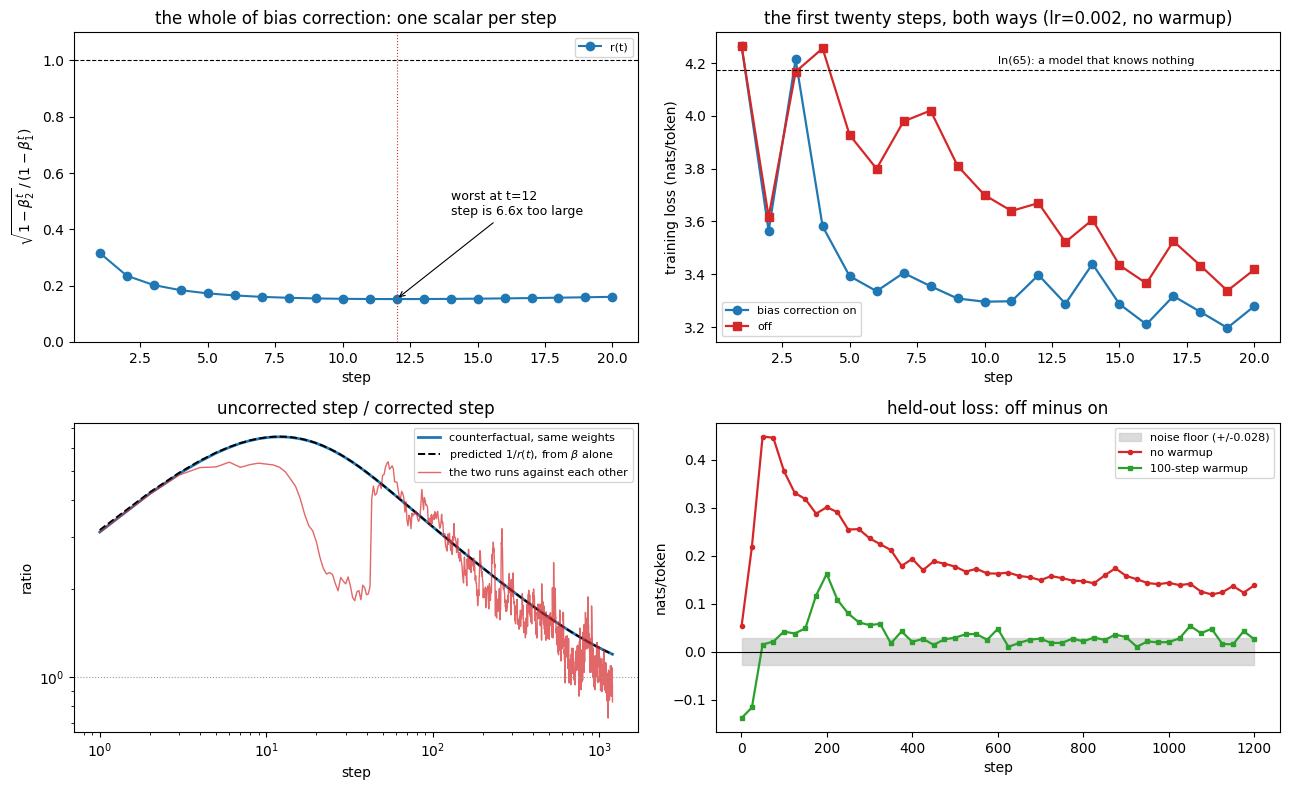

In [18]:
fig, ax = plt.subplots(2, 2, figsize=(13, 8))

ax[0, 0].plot(range(1, 21), [r for _, r in rows20], "o-", color="#1f77b4", label="r(t)")
ax[0, 0].axhline(1.0, color="k", lw=0.8, ls="--")
ax[0, 0].axvline(t_min, color="#d62728", lw=0.8, ls=":")
ax[0, 0].annotate(f"worst at t={t_min}\nstep is {1 / r_min:.1f}x too large",
                  xy=(t_min, r_min), xytext=(t_min + 2, 0.45), fontsize=9,
                  arrowprops=dict(arrowstyle="->", lw=0.8))
ax[0, 0].set_title("the whole of bias correction: one scalar per step")
ax[0, 0].set_xlabel("step"); ax[0, 0].set_ylabel(r"$\sqrt{1-\beta_2^t}\,/\,(1-\beta_1^t)$")
ax[0, 0].set_ylim(0, 1.1); ax[0, 0].legend(fontsize=8)

ax[0, 1].plot(range(1, 21), bc_on["loss"][:20], "o-", label="bias correction on", lw=1.6)
ax[0, 1].plot(range(1, 21), bc_off["loss"][:20], "s-", label="off", lw=1.6, color="#d62728")
ax[0, 1].axhline(RESULTS["uniform_loss"], color="k", lw=0.8, ls="--")
ax[0, 1].text(10.5, RESULTS["uniform_loss"] + 0.02, "ln(65): a model that knows nothing",
              fontsize=8)
ax[0, 1].set_title(f"the first twenty steps, both ways (lr={BC_LR}, no warmup)")
ax[0, 1].set_xlabel("step"); ax[0, 1].set_ylabel("training loss (nats/token)")
ax[0, 1].legend(fontsize=8)

ax[1, 0].plot(range(1, BC_STEPS + 1), cf, lw=2.0, color="#1f77b4",
              label="counterfactual, same weights")
ax[1, 0].plot(range(1, BC_STEPS + 1), ratio_pred, "--", lw=1.4, color="k",
              label=r"predicted $1/r(t)$, from $\beta$ alone")
ax[1, 0].plot(range(1, BC_STEPS + 1), ratio_meas, lw=1.0, color="#d62728", alpha=0.7,
              label="the two runs against each other")
ax[1, 0].axhline(1.0, color="#999", lw=0.8, ls=":")
ax[1, 0].set_xscale("log"); ax[1, 0].set_yscale("log")
ax[1, 0].set_title("uncorrected step / corrected step")
ax[1, 0].set_xlabel("step"); ax[1, 0].set_ylabel("ratio"); ax[1, 0].legend(fontsize=8)

ax[1, 1].fill_between(ev_steps, -NOISE_FLOOR, NOISE_FLOOR, color="#cccccc", alpha=0.7,
                      label=f"noise floor (+/-{NOISE_FLOOR:.3f})")
ax[1, 1].plot(ev_steps, ev_off - ev_on, "o-", lw=1.6, ms=3, color="#d62728",
              label="no warmup")
ax[1, 1].plot(wu_on["eval_steps"],
              np.array(wu_off["eval_loss"]) - np.array(wu_on["eval_loss"]),
              "s-", lw=1.6, ms=3, color="#2ca02c", label=f"{WU}-step warmup")
ax[1, 1].axhline(0, color="k", lw=0.8)
ax[1, 1].set_title("held-out loss: off minus on")
ax[1, 1].set_xlabel("step"); ax[1, 1].set_ylabel("nats/token"); ax[1, 1].legend(fontsize=8)

fig.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "bias_correction.png"), dpi=130)
show(fig)
del bc_on, bc_off, wu_on, wu_off
torch.cuda.empty_cache() if device.type == "cuda" else None

## 3. The update-to-weight ratio, every layer, every step

The single most useful number to log during training, and the one this course will need
when the model gets wider:

$$\rho_\ell(t) \;=\; \frac{\mathrm{RMS}(\Delta w_\ell)}{\mathrm{RMS}(w_\ell)}$$

It answers a question the loss cannot: *is this layer moving at a sensible speed?* A
gradient norm tells you nothing on its own, because Adam has already thrown the gradient's
scale away — `RMS(Δw)` is roughly `η` for every parameter, whatever its gradient was. So
the thing that varies between layers is the denominator, and the ratio is what says whether
`η` is large or small **for that layer**. The folklore band is `1e-3`: a layer moving at
`1e-2` is rewriting itself every hundred steps, and one at `1e-5` is frozen.

The question the assignment asks — *at which step does warmup stop changing it?* — has a
trivial answer and an interesting one, and the trivial answer has to be said first because
it makes the interesting one precise. Since

$$\Delta w_\ell = -\eta(t)\cdot\frac{\hat m_\ell}{\sqrt{\hat v_\ell}+\epsilon}
  \quad\Longrightarrow\quad
  \rho_\ell(t) = \eta(t)\cdot\underbrace{\frac{\mathrm{RMS}(\hat m_\ell/(\sqrt{\hat v_\ell}+\epsilon))}{\mathrm{RMS}(w_\ell)}}_{\textstyle \tilde\rho_\ell(t)}$$

warmup enters the ratio **only** through `η(t)`, and therefore stops changing it at exactly
the last warmup step, by construction. The measurable question is the other one: *during*
warmup, is warmup even the thing that is moving the ratio — or is Adam's own transient
moving it more? That is what the decomposition above lets us settle, one step at a time,
and the answer is not the one the schedule suggests.

In [19]:
rule("3. Update-to-weight ratio, logged for every layer at every step")

RATIO_STEPS, RATIO_WARMUP, RATIO_LR = 600, 100, 2e-3
rr = train(steps=RATIO_STEPS, lr=RATIO_LR, schedule="constant", warmup=RATIO_WARMUP,
           log_ratios=True, eval_every=0)

names = list(rr["ratios"].keys())
R = {n: np.array(v) for n, v in rr["ratios"].items()}
lrs = np.array(rr["lr"])
steps_ax = np.arange(1, RATIO_STEPS + 1)

print(f"width {BASE_WIDTH}, lr {RATIO_LR}, {RATIO_WARMUP}-step linear warmup then constant, "
      f"{RATIO_STEPS} steps")
print(f"{len(names)} parameter tensors logged at every step\n")
print(f"{'layer':<24} {'step 1':>10} {'step 10':>10} {'step 50':>10} {'step 100':>10} "
      f"{'step 300':>10} {'step 600':>10}")
print("-" * 90)
for n in names:
    print(f"{n:<24} " + " ".join(f"{R[n][t - 1]:>10.2e}"
                                 for t in (1, 10, 50, 100, 300, 600)))

# The LayerNorm shifts start at exactly zero, so after step 1 the "weight" is entirely the
# update and the ratio is exactly 1.  That is an artefact of the initialisation, not a layer
# moving fast, and it is why the headline spread below is quoted over the matrices and
# embeddings -- the tensors where RMS(w) means something at step 1.
zero_init = [n for n in names if abs(R[n][0] - 1.0) < 1e-9]
matrixy = [n for n in names if "ln" not in n]
print(f"\n{len(zero_init)} tensors read exactly 1.000 at step 1 "
      f"({', '.join(zero_init[:3])}...):")
print(f"  they are the LayerNorm shifts, initialised to zero, so at step 1 the weight IS the")
print(f"  update.  An artefact of the init, not a layer moving fast -- and a reminder that "
      f"this")
print(f"  ratio is only meaningful once a tensor has a scale of its own.")

peak = {n: float(np.median(R[n][RATIO_WARMUP - 5:RATIO_WARMUP + 5])) for n in names}
end = {n: float(np.median(R[n][-50:])) for n in names}
lo = min(matrixy, key=lambda n: peak[n])
hi = max(matrixy, key=lambda n: peak[n])
print(f"\nat the end of warmup (median over steps {RATIO_WARMUP - 5}-{RATIO_WARMUP + 5}), "
      f"over the {len(matrixy)} matrices and embeddings:")
print(f"  slowest : {lo:<22} {peak[lo]:.2e}")
print(f"  fastest : {hi:<22} {peak[hi]:.2e}   ({peak[hi] / peak[lo]:.0f}x the slowest)")
print(f"  the 1e-3 rule of thumb sits "
      f"{'inside' if peak[lo] <= 1e-3 <= peak[hi] else 'above' if 1e-3 < peak[lo] else 'below'}"
      f" that spread -- at lr={RATIO_LR} this model is running the whole band high.")

decay = float(np.median([end[n] / peak[n] for n in matrixy]))
print(f"\nand the thing the word 'plateau' would have hidden: with the learning rate held")
print(f"CONSTANT after step {RATIO_WARMUP}, the ratio does not stay put.  It peaks at the "
      f"end of warmup")
print(f"and then decays -- median {decay:.2f}x by step {RATIO_STEPS} across those tensors -- "
      f"because")
print(f"RMS(dw) is pinned near eta by Adam while RMS(w) keeps growing.  A constant learning")
print(f"rate is not a constant update-to-weight ratio, and the ratio is the one of the two")
print(f"that describes what the model is doing.")
record("ratio_steps", RATIO_STEPS)
record("ratio_warmup", RATIO_WARMUP)
record("ratio_lr", RATIO_LR)
record("ratio_layers", names)
record("ratio_zero_init", zero_init)
record("ratio_table", {n: [float(R[n][t - 1]) for t in (1, 10, 50, 100, 300, 600)]
                       for n in names})
record("ratio_peak", peak)
record("ratio_end", end)
record("ratio_slowest", lo)
record("ratio_fastest", hi)
record("ratio_spread", peak[hi] / peak[lo])
record("ratio_decay", decay)


3. Update-to-weight ratio, logged for every layer at every step   [t+2m13s]


width 256, lr 0.002, 100-step linear warmup then constant, 600 steps
21 parameter tensors logged at every step

layer                        step 1    step 10    step 50   step 100   step 300   step 600
------------------------------------------------------------------------------------------
wte.weight                 9.28e-04   5.60e-03   1.21e-02   1.35e-02   8.92e-03   4.76e-03
wpe.weight                 1.00e-03   3.91e-03   1.21e-02   1.84e-02   1.25e-02   7.71e-03
h.0.ln1.weight             2.00e-05   9.00e-05   3.21e-04   8.71e-04   8.14e-04   9.33e-04
h.0.ln1.bias               1.00e+00   1.20e-01   4.39e-02   5.16e-02   2.65e-02   1.46e-02
h.0.ln2.weight             2.00e-05   1.21e-04   2.24e-04   3.77e-04   4.62e-04   4.39e-04
h.0.ln2.bias               1.00e+00   1.27e-01   8.26e-02   1.08e-01   1.40e-02   5.01e-03
h.0.attn.weight            1.00e-03   5.35e-03   1.55e-02   2.29e-02   1.50e-02   9.24e-03
h.0.attn_proj.weight       2.00e-03   8.42e-03   1.56e-02   2.65e-02 

0.6099500249165021

### Which of the two is moving the ratio, step by step

`log ρ = log η + log ρ̃`. Differencing that gives the contribution of warmup and the
contribution of everything else to each step's change in the ratio, in the same units, and
the crossing point is a measurement rather than a reading of the schedule.

In [20]:
rule("3b. Warmup's share of the movement, step by step")

rho_tilde = {n: R[n] / lrs for n in names}
d_lr = np.abs(np.diff(np.log(lrs)))                       # warmup's contribution
tot_all = np.mean([np.abs(np.diff(np.log(R[n]))) for n in names], axis=0)
d_rho = np.mean([np.abs(np.diff(np.log(rho_tilde[n]))) for n in names], axis=0)

print(f"{'step':>6} {'d log lr (warmup)':>20} {'d log rho~ (Adam)':>20} {'who wins':>12}")
print("-" * 62)
for t in (2, 3, 5, 8, 12, 20, 40, 60, 80, 99, 100, 101, 150, 300):
    if t - 2 < len(d_lr):
        w = "warmup" if d_lr[t - 2] > d_rho[t - 2] else "Adam"
        print(f"{t:>6} {d_lr[t - 2]:>20.4f} {d_rho[t - 2]:>20.4f} {w:>12}")

wins = d_lr[:RATIO_WARMUP - 1] > d_rho[:RATIO_WARMUP - 1]   # step s sits at index s-2
last_win = int(np.where(wins)[0][-1]) + 2 if wins.any() else None
share = float(d_lr[:RATIO_WARMUP - 1].sum()
              / (d_lr[:RATIO_WARMUP - 1].sum() + d_rho[:RATIO_WARMUP - 1].sum()))
print(f"\nThis is the opposite of what the schedule suggests.  Warmup's per-step "
      f"contribution is\nlog((t+1)/t), which is 0.69 at step 2 and falls like 1/t; Adam's is "
      f"roughly flat.  So:")
print(f"\n  warmup is the larger term for steps 2 to {last_win}")
print(f"  from step {last_win + 1} to the end of warmup at {RATIO_WARMUP}, Adam's own "
      f"transient moves the ratio more")
print(f"  after step {RATIO_WARMUP} the learning rate is constant, d log lr = 0 exactly, and "
      f"warmup contributes nothing")
print(f"\nOver the whole warmup, the schedule accounts for {share * 100:.0f}% of the total "
      f"movement in log ratio,")
print(f"and it spends almost all of that in the first {last_win} steps.")
print(f"\nSo the answer has two halves and they are different numbers:")
print(f"  warmup stops CHANGING the ratio at step {RATIO_WARMUP} -- by construction, since "
      f"eta stops changing;")
print(f"  warmup stops being what DRIVES the ratio at step {last_win}, which is measured, "
      f"and which is")
print(f"  {RATIO_WARMUP // max(last_win, 1)}x earlier than the schedule would lead you to "
      f"believe.")
record("ratio_warmup_dominant_until", last_win)
record("ratio_warmup_share", share)
record("ratio_d_lr", [float(x) for x in d_lr[:RATIO_WARMUP]])
record("ratio_d_rho", [float(x) for x in d_rho[:RATIO_WARMUP]])


3b. Warmup's share of the movement, step by step   [t+2m23s]
  step    d log lr (warmup)    d log rho~ (Adam)     who wins
--------------------------------------------------------------
     2               0.6931               0.3424       warmup
     3               0.4055               0.2082       warmup
     5               0.2231               0.1483       warmup
     8               0.1335               0.1117       warmup
    12               0.0870               0.0596       warmup
    20               0.0513               0.0764         Adam
    40               0.0253               0.0745         Adam
    60               0.0168               0.0876         Adam
    80               0.0126               0.0752         Adam
    99               0.0102               0.0681         Adam
   100               0.0101               0.0811         Adam
   101               0.0000               0.0696         Adam
   150               0.0000               0.0432         Adam
   300 

[0.34241430527704675,
 0.20816127937726034,
 0.15458677039490562,
 0.1483208595934596,
 0.1439517741343296,
 0.12178994398773133,
 0.11169571267771582,
 0.14706349864162865,
 0.11039141819233364,
 0.07741613804829713,
 0.05957459239263382,
 0.046900907512499056,
 0.08701120386542362,
 0.08231677510920737,
 0.049641107004008714,
 0.07171456136306271,
 0.05356335336222521,
 0.043108429663354826,
 0.07636396994829606,
 0.059038336794377276,
 0.04465207547134867,
 0.033646112929204795,
 0.0885714468868126,
 0.032409742324742606,
 0.037419141241027534,
 0.03852068184982745,
 0.0480017920463629,
 0.06884485044300777,
 0.08302780822011016,
 0.113584545362349,
 0.06652641977134749,
 0.03508303288160751,
 0.05779554174715703,
 0.046768997745418026,
 0.04120340321858259,
 0.03313313529672073,
 0.08813573035882798,
 0.07748952655768382,
 0.07445374640370407,
 0.04369336335045361,
 0.07730315540137897,
 0.04914712350785234,
 0.03696030100368682,
 0.05862827526024573,
 0.02946541038627127,
 0.14540

### Does the ratio catch a wrong parameterisation? No — and that is worth knowing

The update-to-weight ratio is routinely recommended as *the* diagnostic for whether a model
is parameterised correctly at a new width, which is section 5's whole subject. So it is
worth four short runs to check whether it actually is one. It is not, and the reason is
arithmetic rather than empirical:

| | `RMS(Δw)` | `RMS(w)` | their ratio |
|---|---|---|---|
| SP at width `m·256` | `∝ η` | `∝ 0.02` | `∝ 1` |
| μP at width `m·256` | `∝ η/m` | `∝ 0.02/√m` | `∝ 1/√m` |

μP shrinks the update **and** the initialisation, and the ratio only sees their quotient —
so μP's ratio is *supposed* to drift, by `1/√m`. The prediction for a 4× width change is
`1.00×` under SP and `0.50×` under μP.

In [21]:
rule("3c. The same ratio at two widths, under both parameterisations")

CMP_STEPS = 150
cmp_runs = {}
for pz in ("sp", "mup"):
    for w in (BASE_WIDTH, 1024):
        cmp_runs[(pz, w)] = train(width=w, steps=CMP_STEPS, lr=RATIO_LR, schedule="constant",
                                  warmup=RATIO_WARMUP, parameterization=pz, log_ratios=True)

def matrix_ratio(run):
    """Median ratio over the hidden matrices after warmup -- the tensors muP rescales."""
    vals = [float(np.median(np.array(v)[RATIO_WARMUP:]))
            for k, v in run["ratios"].items()
            if k.startswith("h.") and k.endswith(".weight")]
    return float(np.median(vals))


print(f"median update-to-weight ratio of the hidden matrices, after warmup, "
      f"{CMP_STEPS} steps, lr={RATIO_LR}\n")
print(f"{'':<8} {'width 256':>12} {'width 1024':>12} {'measured':>10} {'predicted':>11}")
print("-" * 58)
drift = {}
for pz, pred in (("sp", 1.00), ("mup", 0.50)):
    a_, b_ = matrix_ratio(cmp_runs[(pz, BASE_WIDTH)]), matrix_ratio(cmp_runs[(pz, 1024)])
    drift[pz] = b_ / a_
    print(f"{pz:<8} {a_:>12.2e} {b_:>12.2e} {b_ / a_:>9.2f}x {pred:>10.2f}x")
print(f"\nSo the ratio does NOT separate them: {drift['sp']:.2f}x against "
      f"{drift['mup']:.2f}x, a difference of")
print(f"{abs(drift['sp'] - drift['mup']) / drift['mup'] * 100:.0f}% where the theory asks "
      f"for 2x.  muP lands on its prediction; SP misses its own badly.")
print(f"\nThe reason SP misses is worth more than the check: at lr={RATIO_LR}, width 1024 is "
      f"far past")
print(f"SP's optimum (section 5 puts it near 5e-04 there), so that arm is training badly and "
      f"its")
print(f"weights are growing for reasons that have nothing to do with parameterisation.  The")
print(f"diagnostic is confounded by exactly the condition it is supposed to detect.")
print(f"\nCONCLUSION, against the folklore: the update-to-weight ratio is a good instrument "
      f"for")
print(f"'is this layer moving at a sane speed', and a bad one for 'is this model "
      f"parameterised")
print(f"correctly at a new width'.  The quantity that answers the second question is the "
      f"scale of")
print(f"the activations, and section 5e measures it.")
record("ratio_cmp_steps", CMP_STEPS)
record("ratio_cmp", {f"{pz}_{w}": matrix_ratio(cmp_runs[(pz, w)])
                     for pz in ("sp", "mup") for w in (BASE_WIDTH, 1024)})
record("ratio_drift_sp", drift["sp"])
record("ratio_drift_mup", drift["mup"])
record("ratio_drift_sp_pred", 1.0)
record("ratio_drift_mup_pred", 0.5)


3c. The same ratio at two widths, under both parameterisations   [t+2m23s]


median update-to-weight ratio of the hidden matrices, after warmup, 150 steps, lr=0.002

            width 256   width 1024   measured   predicted
----------------------------------------------------------
sp           1.26e-02     7.22e-03      0.57x       1.00x
mup          1.26e-02     6.77e-03      0.54x       0.50x

So the ratio does NOT separate them: 0.57x against 0.54x, a difference of
7% where the theory asks for 2x.  muP lands on its prediction; SP misses its own badly.

The reason SP misses is worth more than the check: at lr=0.002, width 1024 is far past
SP's optimum (section 5 puts it near 5e-04 there), so that arm is training badly and its
weights are growing for reasons that have nothing to do with parameterisation.  The
diagnostic is confounded by exactly the condition it is supposed to detect.

CONCLUSION, against the folklore: the update-to-weight ratio is a good instrument for
'is this layer moving at a sane speed', and a bad one for 'is this model parameterised
corr

0.5

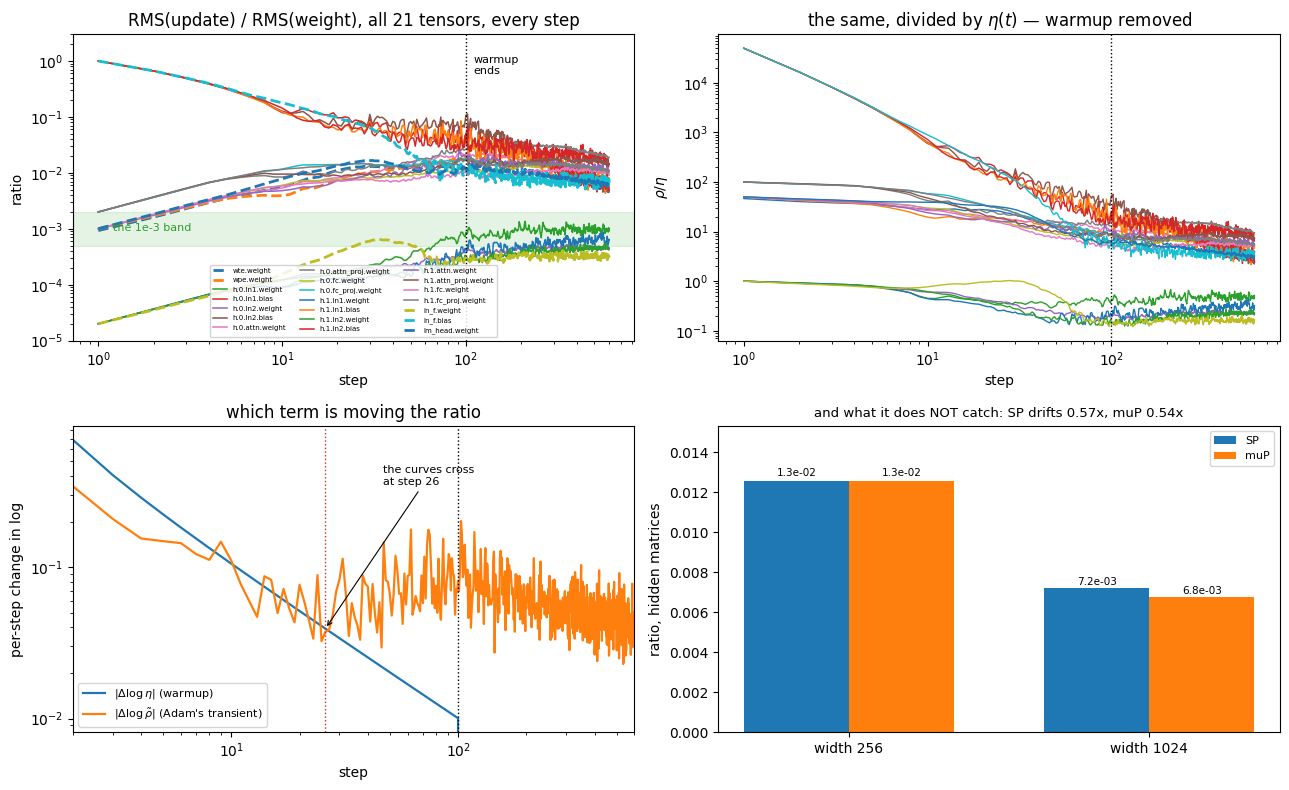

In [22]:
fig, ax = plt.subplots(2, 2, figsize=(13, 8))

for n in names:
    style = dict(lw=1.1) if n.startswith("h.") else dict(lw=2.0, ls="--")
    ax[0, 0].plot(steps_ax, R[n], label=n, **style)
ax[0, 0].axvline(RATIO_WARMUP, color="k", lw=1.0, ls=":")
ax[0, 0].text(RATIO_WARMUP * 1.1, 1.3e0, "warmup\nends", fontsize=8, va="top")
ax[0, 0].axhspan(5e-4, 2e-3, color="#2ca02c", alpha=0.12)
ax[0, 0].text(1.2, 9e-4, "the 1e-3 band", fontsize=8, color="#2ca02c")
ax[0, 0].set_yscale("log"); ax[0, 0].set_xscale("log")
ax[0, 0].set_ylim(1e-5, 3e0)
ax[0, 0].set_title(f"RMS(update) / RMS(weight), all {len(names)} tensors, every step")
ax[0, 0].set_xlabel("step"); ax[0, 0].set_ylabel("ratio")
ax[0, 0].legend(fontsize=5.0, ncol=3, loc="lower center", framealpha=0.85)

for n in names:
    ax[0, 1].plot(steps_ax, rho_tilde[n], lw=1.0)
ax[0, 1].axvline(RATIO_WARMUP, color="k", lw=1.0, ls=":")
ax[0, 1].set_yscale("log"); ax[0, 1].set_xscale("log")
ax[0, 1].set_title(r"the same, divided by $\eta(t)$ — warmup removed")
ax[0, 1].set_xlabel("step"); ax[0, 1].set_ylabel(r"$\rho/\eta$")

ax[1, 0].plot(np.arange(2, RATIO_STEPS + 1), d_lr, lw=1.6, label=r"$|\Delta\log\eta|$ (warmup)")
ax[1, 0].plot(np.arange(2, RATIO_STEPS + 1), d_rho, lw=1.6,
              label=r"$|\Delta\log\tilde\rho|$ (Adam's transient)")
if last_win:
    ax[1, 0].axvline(last_win, color="#d62728", lw=1.0, ls=":")
    ax[1, 0].annotate(f"the curves cross\nat step {last_win}",
                      xy=(last_win, d_lr[last_win - 2]),
                      xytext=(last_win * 1.8, 0.35), fontsize=8,
                      arrowprops=dict(arrowstyle="->", lw=0.8))
ax[1, 0].axvline(RATIO_WARMUP, color="k", lw=1.0, ls=":")
ax[1, 0].set_xscale("log"); ax[1, 0].set_yscale("log"); ax[1, 0].set_xlim(2, RATIO_STEPS)
ax[1, 0].set_title("which term is moving the ratio")
ax[1, 0].set_xlabel("step"); ax[1, 0].set_ylabel("per-step change in log"); ax[1, 0].legend(fontsize=8)

xs = np.arange(2)
w_ = 0.35
for i, pz in enumerate(("sp", "mup")):
    vals = [matrix_ratio(cmp_runs[(pz, w)]) for w in (BASE_WIDTH, 1024)]
    bars = ax[1, 1].bar(xs + i * w_, vals, w_,
                        label="SP" if pz == "sp" else "muP")
    for b, v in zip(bars, vals):
        ax[1, 1].text(b.get_x() + b.get_width() / 2, v * 1.02, f"{v:.1e}",
                      ha="center", fontsize=7.5)
ax[1, 1].set_xticks(xs + w_ / 2)
ax[1, 1].set_xticklabels([f"width {BASE_WIDTH}", "width 1024"])
ax[1, 1].set_ylim(0, max(matrix_ratio(cmp_runs[(pz, w)])
                         for pz in ("sp", "mup") for w in (BASE_WIDTH, 1024)) * 1.22)
ax[1, 1].set_ylabel("ratio, hidden matrices")
ax[1, 1].set_title(f"and what it does NOT catch: SP drifts {drift['sp']:.2f}x, "
                   f"muP {drift['mup']:.2f}x", fontsize=9.5)
ax[1, 1].legend(fontsize=8, loc="upper right")

fig.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "update_ratio.png"), dpi=130)
show(fig)
np.savez_compressed(os.path.join(OUT_DIR, "ratio_log.npz"),
                    lr=lrs, **{n.replace(".", "_"): R[n] for n in names})
del rr, cmp_runs
torch.cuda.empty_cache() if device.type == "cuda" else None

## 4. Cosine against WSD, both tuned, both stopped at 200

The assignment says: train the same model twice for 300 steps, once under cosine and once
under WSD, stop both at step 200, report both losses, and say which model you would keep.

Doing exactly that produces a number and a wrong conclusion, so this section does exactly
that **and then** says why the number is not the answer. The reason is in the schedules
themselves:

* **Cosine** is a function of the total budget. `η(t) = η_min + ½(η_max-η_min)(1+cos(πt/T))`
  contains `T`. Declare 300 and stop at 200 and the model is caught two-thirds of the way
  down a ramp that was aimed somewhere else — it has neither the high learning rate that
  would still be exploring nor the low one that would have consolidated.
* **WSD** holds `η_max` flat and spends the last fraction of the budget cooling down. Its
  claim is precisely that the cooldown can be launched from *any* point in the stable
  phase, so the budget does not have to be declared in advance.

"Stop both at 200" is therefore a question about budget, and the two schedules answer it
differently. Four arms, every one of them with its own tuned peak learning rate, because a
schedule comparison at a single shared learning rate is a comparison of learning rates.

In [23]:
rule("4. Tuning both schedules before comparing them")

SCHED_STEPS, SCHED_WARMUP, STOP_AT = 300, 20, 200
LR_GRID = [5e-4, 1e-3, 2e-3, 4e-3, 8e-3]


def sweep(lrs, label, **kw):
    """The same grid, the same budget, for every arm -- that is what 'tuned' has to mean."""
    out = []
    for lr in lrs:
        r = train(lr=lr, **kw)
        out.append((lr, r["final_eval"]))
        del r
        torch.cuda.empty_cache() if device.type == "cuda" else None
    best = min(out, key=lambda x: x[1])
    print(f"  {label:<28} " + "  ".join(f"{lr:.0e}:{v:.4f}" for lr, v in out)
          + f"   -> best lr {best[0]:.0e}")
    return out, best[0]


print(f"grid: {['%.0e' % x for x in LR_GRID]}, {len(LR_GRID)} trials per arm, "
      f"selection on held-out loss at each arm's own horizon\n")
cos300_sweep, cos300_lr = sweep(LR_GRID, "cosine, 300-step budget", steps=SCHED_STEPS,
                                schedule="cosine", warmup=SCHED_WARMUP)
wsd300_sweep, wsd300_lr = sweep(LR_GRID, "WSD, 300-step budget", steps=SCHED_STEPS,
                                schedule="wsd", warmup=SCHED_WARMUP, wsd_decay_frac=0.2)
cos200_sweep, cos200_lr = sweep(LR_GRID, "cosine, 200-step budget", steps=STOP_AT,
                                schedule="cosine", warmup=SCHED_WARMUP)
wsd200_sweep, wsd200_lr = sweep(LR_GRID, "WSD cooled into 200", steps=STOP_AT,
                                schedule="wsd", warmup=SCHED_WARMUP, wsd_decay_frac=0.2)
record("sched_steps", SCHED_STEPS)
record("sched_stop_at", STOP_AT)
record("sched_warmup", SCHED_WARMUP)
record("sched_lr_grid", LR_GRID)
record("sched_sweeps", dict(cos300=cos300_sweep, wsd300=wsd300_sweep,
                            cos200=cos200_sweep, wsd200=wsd200_sweep))
record("sched_best_lrs", dict(cos300=cos300_lr, wsd300=wsd300_lr,
                              cos200=cos200_lr, wsd200=wsd200_lr))


4. Tuning both schedules before comparing them   [t+3m04s]
grid: ['5e-04', '1e-03', '2e-03', '4e-03', '8e-03'], 5 trials per arm, selection on held-out loss at each arm's own horizon



  cosine, 300-step budget      5e-04:2.3454  1e-03:2.2380  2e-03:2.1113  4e-03:2.1144  8e-03:2.4836   -> best lr 2e-03


  WSD, 300-step budget         5e-04:2.2405  1e-03:2.0881  2e-03:2.0554  4e-03:2.0967  8e-03:2.4993   -> best lr 2e-03


  cosine, 200-step budget      5e-04:2.4164  1e-03:2.3794  2e-03:2.3555  4e-03:2.3464  8e-03:2.5012   -> best lr 4e-03


  WSD cooled into 200          5e-04:2.3808  1e-03:2.3110  2e-03:2.2121  4e-03:2.2836  8e-03:2.5126   -> best lr 2e-03


{'cos300': 0.002, 'wsd300': 0.002, 'cos200': 0.004, 'wsd200': 0.002}

### The four arms, each at its own best learning rate, three data orders each

Three seeds per arm, because section 0 measured what a single seed is worth. A verdict that
does not clear the noise floor is not a verdict.

In [24]:
rule("4b. The four arms")

ARMS = {
    "cosine, budget 300": dict(steps=SCHED_STEPS, schedule="cosine", lr=cos300_lr),
    "WSD, budget 300": dict(steps=SCHED_STEPS, schedule="wsd", lr=wsd300_lr),
    "cosine, budget 200": dict(steps=STOP_AT, schedule="cosine", lr=cos200_lr),
    "WSD cooled into 200": dict(steps=STOP_AT, schedule="wsd", lr=wsd200_lr),
}
SEEDS = (1337, 1338, 1339)
curves, arm_at_200, arm_at_end = {}, {}, {}
for name, kw in ARMS.items():
    per_seed_200, per_seed_end, first = [], [], None
    for sd in SEEDS:
        r = train(warmup=SCHED_WARMUP, wsd_decay_frac=0.2, eval_every=10, data_seed=sd, **kw)
        ev_s, ev_l = np.array(r["eval_steps"]), np.array(r["eval_loss"])
        per_seed_200.append(float(ev_l[np.argmin(np.abs(ev_s - STOP_AT))]))
        per_seed_end.append(r["final_eval"])
        if first is None:
            first = (ev_s, ev_l, np.array(r["lr"]))
        del r
        torch.cuda.empty_cache() if device.type == "cuda" else None
    curves[name] = first
    arm_at_200[name] = per_seed_200
    arm_at_end[name] = per_seed_end

print(f"held-out loss, mean of {len(SEEDS)} data orders (spread in brackets)")
print(f"{'arm':<24} {'lr':>8} {'at step 200':>22} {'at its own end':>22}")
print("-" * 80)
for name in ARMS:
    a2, ae = arm_at_200[name], arm_at_end[name]
    print(f"{name:<24} {ARMS[name]['lr']:>8.0e} "
          f"{np.mean(a2):>14.4f} [{max(a2) - min(a2):.3f}] "
          f"{np.mean(ae):>14.4f} [{max(ae) - min(ae):.3f}]")

c3 = float(np.mean(arm_at_200["cosine, budget 300"]))
w3 = float(np.mean(arm_at_200["WSD, budget 300"]))
c2 = float(np.mean(arm_at_200["cosine, budget 200"]))
w2 = float(np.mean(arm_at_200["WSD cooled into 200"]))

lit_gap = w3 - c3
lit_resolved = abs(lit_gap) > NOISE_FLOOR
print(f"\nTHE LITERAL ANSWER TO THE ASSIGNMENT -- both budgeted for 300, both stopped at "
      f"{STOP_AT}:")
print(f"  cosine {c3:.4f}   WSD {w3:.4f}   gap {lit_gap:+.4f} nats "
      f"({abs(lit_gap) / NOISE_FLOOR:.1f}x the noise floor)")
if lit_resolved:
    print(f"  {'cosine' if c3 < w3 else 'WSD'} wins, and by a resolvable margin.")
else:
    print(f"\n  AND IT IS A TIE.  {abs(lit_gap):.4f} nats against a noise floor of "
          f"{NOISE_FLOOR:.4f}: the two arms are")
    print(f"  separated by less than the spread of runs that differ only in their data "
          f"order.  The")
    print(f"  comparison the assignment asks for, run carefully with three seeds a side and "
          f"both")
    print(f"  peak learning rates tuned, DOES NOT HAVE AN ANSWER at this scale.  Reporting "
          f"'{'WSD' if w3 < c3 else 'cosine'} wins")
    print(f"  by {abs(lit_gap):.4f}' would be reporting a coin flip.")
print(f"\n  The reason is in the schedules rather than the optimizer: at step {STOP_AT} the "
      f"cosine arm has")
print(f"  already decayed to "
      f"{curves['cosine, budget 300'][2][STOP_AT - 1] / cos300_lr * 100:.0f}% of its peak "
      f"while the WSD arm is still at "
      f"{curves['WSD, budget 300'][2][STOP_AT - 1] / wsd300_lr * 100:.0f}%.  A model at a "
      f"high")
print(f"  learning rate is mid-exploration and its loss is supposed to look worse; a model "
      f"that has")
print(f"  decayed has consolidated and stopped exploring.  Stopping both at the same step "
      f"compares")
print(f"  two different stages of two different plans.")
record("sched_literal_gap", lit_gap)
record("sched_literal_resolved", bool(lit_resolved))
record("sched_arm_at_200", arm_at_200)
record("sched_arm_at_end", arm_at_end)
record("sched_lr_frac_at_200", {
    n: float(curves[n][2][STOP_AT - 1] / ARMS[n]["lr"]) for n in ARMS
    if len(curves[n][2]) >= STOP_AT})


4b. The four arms   [t+3m59s]


held-out loss, mean of 3 data orders (spread in brackets)
arm                            lr            at step 200         at its own end
--------------------------------------------------------------------------------
cosine, budget 300          2e-03         2.2484 [0.015]         2.1050 [0.015]
WSD, budget 300             2e-03         2.2424 [0.020]         2.0478 [0.014]
cosine, budget 200          4e-03         2.3340 [0.048]         2.3340 [0.048]
WSD cooled into 200         2e-03         2.2099 [0.020]         2.2099 [0.020]

THE LITERAL ANSWER TO THE ASSIGNMENT -- both budgeted for 300, both stopped at 200:
  cosine 2.2484   WSD 2.2424   gap -0.0060 nats (0.2x the noise floor)

  AND IT IS A TIE.  0.0060 nats against a noise floor of 0.0282: the two arms are
  separated by less than the spread of runs that differ only in their data order.  The
  comparison the assignment asks for, run carefully with three seeds a side and both
  peak learning rates tuned, DOES NOT HAVE AN ANSW

{'cosine, budget 300': 0.35638435101801436,
 'WSD, budget 300': 1.0,
 'cosine, budget 200': 0.1,
 'WSD cooled into 200': 0.09999999999999998}

### Which model would I keep

Not the one that wins the comparison as posed. The comparison as posed asks which of two
*interrupted* runs is further along, and the honest answer to "which model would you keep"
depends on what happens next.

In [25]:
rule("4c. The verdict")

print(f"at step {STOP_AT}, best to worst:")
for name, v in sorted(arm_at_200.items(), key=lambda kv: np.mean(kv[1])):
    print(f"  {name:<24} {np.mean(v):.4f}")
print(f"\nat each arm's own end:")
for name, v in sorted(arm_at_end.items(), key=lambda kv: np.mean(kv[1])):
    print(f"  {name:<24} {np.mean(v):.4f}  (step "
          f"{ARMS[name]['steps']})")

best200 = min(arm_at_200, key=lambda n: np.mean(arm_at_200[n]))
gap_vs_cos = c3 - w2
print(f"\n1. Of the two arms the assignment names: neither, and not because I dislike the "
      f"question.")
print(f"   {min(c3, w3):.4f} against {max(c3, w3):.4f} is "
      f"{abs(lit_gap) / NOISE_FLOOR:.1f}x the noise floor.  Forced to pick I would take the")
print(f"   {'cosine' if c3 < w3 else 'WSD'} checkpoint, and I would not defend the choice.")
print(f"2. What I would actually keep is '{best200}' at "
      f"{np.mean(arm_at_200[best200]):.4f} --")
print(f"   {c3 - np.mean(arm_at_200[best200]):+.4f} nats better than the stopped cosine arm, "
      f"{abs(gap_vs_cos) / NOISE_FLOOR:.1f}x the noise floor, and")
print(f"   available for the same {STOP_AT} steps of compute.  WSD's cooldown is aimed at "
      f"the step you")
print(f"   intend to stop on; aiming it correctly is worth more than the choice of schedule "
      f"family.")
print(f"3. And the arm that did NOT work, because it is the one I expected to win: cosine "
      f"re-planned")
print(f"   for a {STOP_AT}-step budget is the WORST of the four at "
      f"{np.mean(arm_at_200['cosine, budget 200']):.4f}, despite being tuned")
print(f"   over the same grid and picking a higher peak ({cos200_lr:.0e}) to compensate.  A "
      f"full cosine")
print(f"   decay inside {STOP_AT} steps spends too much of a short run at a low learning "
      f"rate; the arm")
print(f"   that was 'interrupted' had simply taken bigger steps for longer.  At this "
      f"horizon, being")
print(f"   caught mid-decay beats having decayed.")
end_w = float(np.mean(arm_at_end["WSD, budget 300"]))
end_c = float(np.mean(arm_at_end["cosine, budget 300"]))
end_gap = end_w - end_c
resolved = abs(end_gap) > NOISE_FLOOR
print(f"\nAnd the question everyone actually wants answered -- does WSD beat cosine?  At its "
      f"own")
print(f"300-step horizon WSD reaches {end_w:.4f} against cosine's {end_c:.4f}: "
      f"{end_gap:+.4f} nats,")
print(f"{abs(end_gap) / NOISE_FLOOR:.1f}x the noise floor.  "
      + (f"On this run, {'WSD' if end_gap < 0 else 'cosine'} wins, and the margin is "
         f"resolvable."
         if resolved else
         "That is inside the noise floor, so this run does not answer it."))
print(f"\nWhat that does NOT license is the general claim.  This is "
      f"{RESULTS['n_params_base'] / 1e6:.1f}M parameters, "
      f"{SCHED_STEPS} steps,")
print(f"three seeds, one depth, one batch size, and a stable phase "
      f"{SCHED_STEPS - int(0.2 * SCHED_STEPS) - SCHED_WARMUP} steps long.  The published "
      f"WSD results")
print(f"are about runs where that phase is thousands of times longer, and the mechanism "
      f"usually")
print(f"offered for why it works -- that a long high-LR phase finds wider basins -- cannot "
      f"be")
print(f"tested at this scale at all.  A result that agrees with the literature for reasons "
      f"this")
print(f"experiment cannot check is still only one data point.")
print(f"\nWhat this run does establish is narrower and more useful: WSD's cooldown can be "
      f"aimed at")
print(f"a stopping point chosen after the run started, and doing so is worth "
      f"{gap_vs_cos:+.4f} nats against")
print(f"a cosine schedule that had to commit to its horizon in advance.")
record("sched_verdict_best_at_200", best200)
record("sched_wsd_cooled_vs_cosine", gap_vs_cos)
record("sched_end_gap",
       float(np.mean(arm_at_end["WSD, budget 300"])
             - np.mean(arm_at_end["cosine, budget 300"])))


4c. The verdict   [t+4m48s]
at step 200, best to worst:
  WSD cooled into 200      2.2099
  WSD, budget 300          2.2424
  cosine, budget 300       2.2484
  cosine, budget 200       2.3340

at each arm's own end:
  WSD, budget 300          2.0478  (step 300)
  cosine, budget 300       2.1050  (step 300)
  WSD cooled into 200      2.2099  (step 200)
  cosine, budget 200       2.3340  (step 200)

1. Of the two arms the assignment names: neither, and not because I dislike the question.
   2.2424 against 2.2484 is 0.2x the noise floor.  Forced to pick I would take the
   WSD checkpoint, and I would not defend the choice.
2. What I would actually keep is 'WSD cooled into 200' at 2.2099 --
   +0.0385 nats better than the stopped cosine arm, 1.4x the noise floor, and
   available for the same 200 steps of compute.  WSD's cooldown is aimed at the step you
   intend to stop on; aiming it correctly is worth more than the choice of schedule family.
3. And the arm that did NOT work, because it

-0.05716462930043553

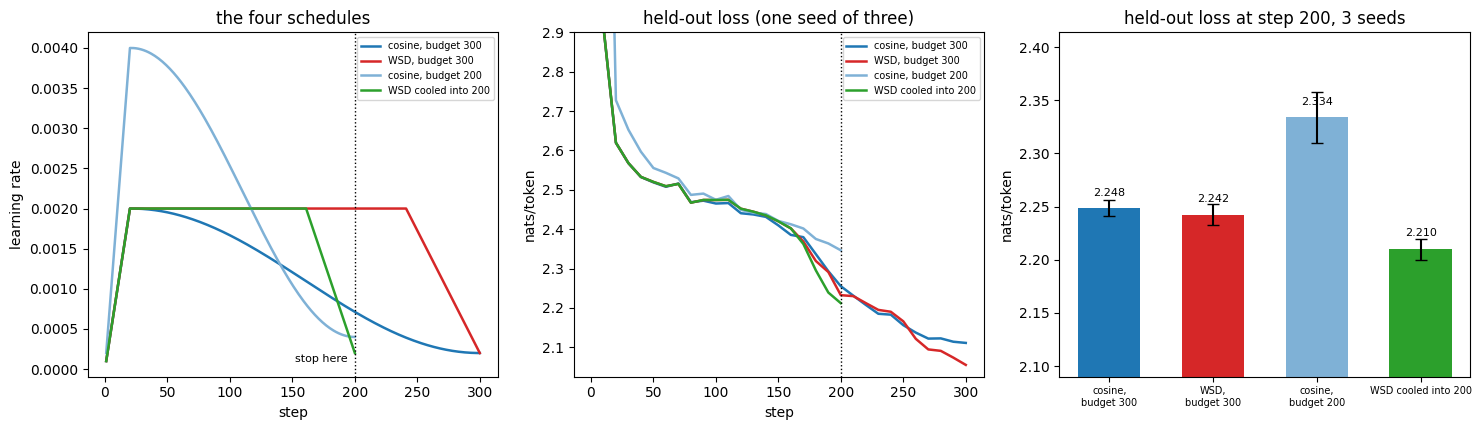

In [26]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4.4))

colors = {"cosine, budget 300": "#1f77b4", "WSD, budget 300": "#d62728",
          "cosine, budget 200": "#7fb1d6", "WSD cooled into 200": "#2ca02c"}
for name, (ev_s, ev_l, lrc) in curves.items():
    ax[0].plot(np.arange(1, len(lrc) + 1), lrc, lw=1.8, color=colors[name], label=name)
ax[0].axvline(STOP_AT, color="k", lw=1.0, ls=":")
ax[0].text(STOP_AT - 6, ax[0].get_ylim()[1] * 0.02, "stop here", fontsize=8, color="k",
           ha="right")
ax[0].set_title("the four schedules"); ax[0].set_xlabel("step")
ax[0].set_ylabel("learning rate"); ax[0].legend(fontsize=7)

_floor = min(min(ev_l) for _, ev_l, _ in curves.values())
for name, (ev_s, ev_l, _) in curves.items():
    ax[1].plot(ev_s, ev_l, lw=1.8, color=colors[name], label=name)
ax[1].axvline(STOP_AT, color="k", lw=1.0, ls=":")
ax[1].set_title("held-out loss (one seed of three)"); ax[1].set_xlabel("step")
ax[1].set_ylabel("nats/token"); ax[1].set_ylim(_floor - 0.03, 2.9)
ax[1].legend(fontsize=7)

xs = np.arange(len(ARMS))
means = [np.mean(arm_at_200[n]) for n in ARMS]
errs = [(max(arm_at_200[n]) - min(arm_at_200[n])) / 2 for n in ARMS]
ax[2].bar(xs, means, 0.6, yerr=errs, capsize=4,
          color=[colors[n] for n in ARMS])
ax[2].set_xticks(xs)
ax[2].set_xticklabels([n.replace(", ", ",\n") for n in ARMS], fontsize=7)
ax[2].set_ylim(min(means) - 0.12, max(means) + 0.08)
ax[2].set_title(f"held-out loss at step {STOP_AT}, 3 seeds")
ax[2].set_ylabel("nats/token")
for x, m in zip(xs, means):
    ax[2].text(x, m + 0.012, f"{m:.3f}", ha="center", fontsize=8)

fig.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "schedules.png"), dpi=130)
show(fig)

## 5. Sweeping the learning rate at three widths

The question behind this section is the one the course actually has to answer: a small
model is cheap to tune and the model that ships is not, so the tuning has to **transfer**.
Sweep the learning rate at widths 256, 512 and 1024, mark the three minima, and say what to
use at 4096.

Done in the obvious parameterisation, that extrapolation is a guess. Standard
parameterisation gives every tensor the same learning rate, so as the model gets wider the
same `η` drives a different model — 5e measures that directly, and it is the coordinate
scales rather than section 3's update-to-weight ratio that show it. μP is the rule built to
remove the drift: hidden and readout matrices are initialised `∝ 1/√fan_in` and given
`η/m`, while embeddings and LayerNorm gains keep `η`. Its claim is that the optimum then
sits at the same place at every width — which is a falsifiable claim, so this section
falsifies or fails to falsify it rather than citing it.

So the sweep is run **twice**, which is the only way the extrapolation becomes a measurement
instead of a preference. Note one thing before the numbers: at the base width `m = 1`, so
the two parameterisations are the *same model with the same learning rates*. The width-256
rows must come out identical, and if they do not, the μP implementation is wrong.

In [27]:
rule("5. Learning-rate sweep at widths 256, 512 and 1024, in SP and muP")

SWEEP_WIDTHS = [256, 512, 1024]
# Eight points rather than seven: SP's optimum falls a factor of four per doubling of width,
# so a grid that brackets width 256 does not bracket width 1024, and an optimum sitting on
# the edge of a grid is not a measured optimum.  The same grid is used for both
# parameterisations, so neither is handicapped by where it was placed.
SWEEP_LRS = [1.25e-4, 2.5e-4, 5e-4, 1e-3, 2e-3, 4e-3, 8e-3, 1.6e-2]
SWEEP_STEPS, SWEEP_WARMUP = 200, 20

sweeps = {}
for pz in ("sp", "mup"):
    for w in SWEEP_WIDTHS:
        row = []
        for lr in SWEEP_LRS:
            r = train(width=w, steps=SWEEP_STEPS, lr=lr, schedule="cosine",
                      warmup=SWEEP_WARMUP, parameterization=pz)
            row.append(r["final_eval"])
            del r
            torch.cuda.empty_cache() if device.type == "cuda" else None
        sweeps[(pz, w)] = row
        print(f"  {pz:4s} width {w:>5} : " + "  ".join(f"{v:6.3f}" for v in row))

base_identical = max(abs(a - b) for a, b in zip(sweeps[("sp", 256)], sweeps[("mup", 256)]))
print(f"\nsanity: at the base width the two parameterisations must be the same model.")
print(f"  largest difference across the {len(SWEEP_LRS)} learning rates : {base_identical:.2e}")
record("sweep_widths", SWEEP_WIDTHS)
record("sweep_lrs", SWEEP_LRS)
record("sweep_steps", SWEEP_STEPS)
record("sweep_curves", {f"{pz}_{w}": sweeps[(pz, w)]
                        for pz in ("sp", "mup") for w in SWEEP_WIDTHS})
record("sweep_base_identical", base_identical)


5. Learning-rate sweep at widths 256, 512 and 1024, in SP and muP   [t+4m49s]


  sp   width   256 :  2.521   2.460   2.416   2.379   2.356   2.346   2.501   2.853


  sp   width   512 :  2.418   2.363   2.302   2.164   2.438   2.514   2.635   2.897


  sp   width  1024 :  2.368   2.304   2.236   2.438   2.488   2.552   2.741   2.949


  mup  width   256 :  2.521   2.460   2.416   2.379   2.356   2.346   2.501   2.853


  mup  width   512 :  2.479   2.432   2.392   2.356   2.314   2.209   2.498   2.747


  mup  width  1024 :  2.459   2.422   2.378   2.339   2.277   2.238   2.495   2.678

sanity: at the base width the two parameterisations must be the same model.
  largest difference across the 8 learning rates : 0.00e+00


0.0

### The minima, refined off the grid

The grid is spaced a factor of two apart, so reading the minimum off it carries ±0.15 in
`log₁₀ η` before anything else. Fitting a parabola through the best point and its two
neighbours gives a better estimate and, more usefully, refuses to give one when the best
point is at the edge of the grid — which is a real outcome and not one to hide.

In [28]:
def refine(lrs, losses):
    """Vertex of the parabola through the best grid point and its neighbours, in log10 lr."""
    i = int(np.argmin(losses))
    if i == 0 or i == len(losses) - 1:
        return lrs[i], False              # at the edge: the grid did not bracket it
    x = np.log10(lrs[i - 1:i + 2])
    y = np.array(losses[i - 1:i + 2])
    a, b, _ = np.polyfit(x, y, 2)
    if a <= 0:
        return lrs[i], False              # not a minimum
    return float(10 ** (-b / (2 * a))), True


rule("5b. The three minima")
print(f"{'':<6} {'width':>7} {'grid best':>12} {'refined':>12} {'bracketed':>11} "
      f"{'loss at best':>13}")
print("-" * 66)
minima = {}
for pz in ("sp", "mup"):
    for w in SWEEP_WIDTHS:
        row = sweeps[(pz, w)]
        grid_best = SWEEP_LRS[int(np.argmin(row))]
        ref, ok = refine(SWEEP_LRS, row)
        minima[(pz, w)] = ref
        print(f"{pz:<6} {w:>7} {grid_best:>12.2e} {ref:>12.2e} {str(ok):>11} "
              f"{min(row):>13.4f}")

sp_shift = minima[("sp", 1024)] / minima[("sp", 256)]
mup_shift = minima[("mup", 1024)] / minima[("mup", 256)]
print(f"\nacross a 4x change in width, the optimum moves by")
print(f"  SP  : {sp_shift:.3f}x")
print(f"  muP : {mup_shift:.3f}x")
record("sweep_minima", {f"{pz}_{w}": minima[(pz, w)]
                        for pz in ("sp", "mup") for w in SWEEP_WIDTHS})
record("sweep_sp_shift", sp_shift)
record("sweep_mup_shift", mup_shift)


5b. The three minima   [t+12m09s]
         width    grid best      refined   bracketed  loss at best
------------------------------------------------------------------
sp         256     4.00e-03     2.94e-03        True        2.3464
sp         512     1.00e-03     8.92e-04        True        2.1642
sp        1024     5.00e-04     4.21e-04        True        2.2356
mup        256     4.00e-03     2.94e-03        True        2.3464
mup        512     4.00e-03     3.40e-03        True        2.2086
mup       1024     4.00e-03     3.10e-03        True        2.2384

across a 4x change in width, the optimum moves by
  SP  : 0.143x
  muP : 1.054x


1.0541849346995542

### Extrapolating to width 4096, two ways

Under SP the only honest method is to fit the drift and extend it, which means trusting a
power law fitted to three points to survive two more doublings. Under μP there is nothing
to extrapolate: the answer is the base width's optimum, and the width multiple does the
rest inside the optimizer.

In [29]:
rule("5c. What to use at width 4096")

lw = np.log2(np.array(SWEEP_WIDTHS, dtype=float))
sp_fit = np.polyfit(lw, np.log2([minima[("sp", w)] for w in SWEEP_WIDTHS]), 1)
mup_fit = np.polyfit(lw, np.log2([minima[("mup", w)] for w in SWEEP_WIDTHS]), 1)
sp_resid = np.log2([minima[("sp", w)] for w in SWEEP_WIDTHS]) - np.polyval(sp_fit, lw)
sp_pred_4096 = float(2 ** np.polyval(sp_fit, math.log2(4096)))
sp_pred_2048 = float(2 ** np.polyval(sp_fit, math.log2(2048)))
mup_pred = float(minima[("mup", 256)])

print(f"fitting log2(lr*) against log2(width) over the three widths:\n")
print(f"  SP  : exponent {sp_fit[0]:+.3f}   residuals "
      f"{', '.join(f'{r:+.2f}' for r in sp_resid)} in log2")
print(f"  muP : exponent {mup_fit[0]:+.3f}")
print(f"\nThose two exponents are the entire section.  Zero means the tuning transfers; "
      f"anything")
print(f"else means it has to be re-done at every width.  muP's theory for Adam predicts -1 "
      f"for SP's")
print(f"hidden layers and 0 for muP; measured, {sp_fit[0]:+.2f} and {mup_fit[0]:+.2f}.")
print(f"\nSP  -> width 2048 : {sp_pred_2048:.2e}")
print(f"       width 4096 : {sp_pred_4096:.2e}   (a power law fitted to three points, "
      f"extended two doublings)")
print(f"muP -> width 2048 and 4096 : {mup_pred:.2e}, the base width's own optimum, "
      f"unchanged")
if abs(mup_fit[0]) > 0.25:
    print(f"\n  Note, against my own framing: muP's exponent is {mup_fit[0]:+.2f}, not 0.  "
          f"The transfer is")
    print(f"  much better than SP's but it is not perfect here, and 5d is where that costs "
          f"something.")
record("sweep_sp_exponent", float(sp_fit[0]))
record("sweep_mup_exponent", float(mup_fit[0]))
record("sweep_sp_pred_2048", sp_pred_2048)
record("sweep_sp_pred_4096", sp_pred_4096)
record("sweep_mup_pred", mup_pred)


5c. What to use at width 4096   [t+12m09s]
fitting log2(lr*) against log2(width) over the three widths:

  SP  : exponent -1.401   residuals +0.11, -0.21, +0.11 in log2
  muP : exponent +0.038

Those two exponents are the entire section.  Zero means the tuning transfers; anything
else means it has to be re-done at every width.  muP's theory for Adam predicts -1 for SP's
hidden layers and 0 for muP; measured, -1.40 and +0.04.

SP  -> width 2048 : 1.48e-04
       width 4096 : 5.61e-05   (a power law fitted to three points, extended two doublings)
muP -> width 2048 and 4096 : 2.94e-03, the base width's own optimum, unchanged


0.00293904271665337

### The held-out width

Both of the above are predictions, and a prediction that is never tested is a preference.
Width 2048 was not in the sweep. Three learning rates at that width — the prediction and its
two neighbours, same horizon, same everything — turn both claims into something that can
fail.

Width 4096 itself does not fit: at `n_layer=2` it is 402M parameters, and weights, gradients
and Adam's two moments come to 6.4 GiB before a single activation, against 4 GiB of card.
That limit is itself part of the answer to "how confident are you", and is stated as such
rather than worked around.

In [30]:
rule("5d. Held-out check at width 2048")

HELD_W = 2048
held = {}
for pz, centre in (("sp", sp_pred_2048), ("mup", mup_pred)):
    grid = [centre / 2, centre, centre * 2]
    row = []
    for lr in grid:
        r = train(width=HELD_W, steps=SWEEP_STEPS, lr=lr, schedule="cosine",
                  warmup=SWEEP_WARMUP, parameterization=pz)
        row.append(r["final_eval"])
        del r
        torch.cuda.empty_cache() if device.type == "cuda" else None
    held[pz] = (grid, row)
    hit = int(np.argmin(row)) == 1
    print(f"  {pz:4s} predicted {centre:.2e} : " +
          "  ".join(f"{lr:.1e}->{v:.4f}" for lr, v in zip(grid, row)) +
          f"   prediction is the best of three: {hit}")

sp_best_held = held["sp"][1][int(np.argmin(held["sp"][1]))]
mup_best_held = held["mup"][1][int(np.argmin(held["mup"][1]))]
sp_at_pred = held["sp"][1][1]
mup_at_pred = held["mup"][1][1]
print(f"\nat the predicted learning rate, width {HELD_W}:")
print(f"  SP  : {sp_at_pred:.4f}   (best of its three: {sp_best_held:.4f}, "
      f"cost of trusting the fit {sp_at_pred - sp_best_held:+.4f})")
print(f"  muP : {mup_at_pred:.4f}   (best of its three: {mup_best_held:.4f}, "
      f"cost of trusting the transfer {mup_at_pred - mup_best_held:+.4f})")
record("held_width", HELD_W)
record("held_sp_grid", held["sp"][0])
record("held_sp_loss", held["sp"][1])
record("held_mup_grid", held["mup"][0])
record("held_mup_loss", held["mup"][1])
record("held_sp_hit", bool(int(np.argmin(held["sp"][1])) == 1))
record("held_mup_hit", bool(int(np.argmin(held["mup"][1])) == 1))
record("held_sp_cost", sp_at_pred - sp_best_held)
record("held_mup_cost", mup_at_pred - mup_best_held)


5d. Held-out check at width 2048   [t+12m09s]


  sp   predicted 1.48e-04 : 7.4e-05->2.3659  1.5e-04->2.2507  3.0e-04->2.1702   prediction is the best of three: False


  mup  predicted 2.94e-03 : 1.5e-03->2.3187  2.9e-03->2.2107  5.9e-03->2.4683   prediction is the best of three: True

at the predicted learning rate, width 2048:
  SP  : 2.2507   (best of its three: 2.1702, cost of trusting the fit +0.0805)
  muP : 2.2107   (best of its three: 2.2107, cost of trusting the transfer +0.0000)


0.0

### Why μP transfers, in one measurement

The transfer is not magic and it is not an empirical accident: μP is chosen so that the
scale of what flows through the network does not change with width. If the implementation is
right, the coordinates of the residual stream and of the logits stay put as the model gets
wider — at initialisation *and* after a few steps of training, which is the part that is
easy to get wrong. Under SP they do not. This is the check that catches a broken μP, and it
costs four short runs.

In [31]:
rule("5e. Coordinate check -- the reason muP transfers")

COORD_LR = 2e-3
coord = {}
for pz in ("sp", "mup"):
    for w in (256, 1024):
        r = train(width=w, steps=11, lr=COORD_LR, schedule="constant", warmup=0,
                  parameterization=pz, coord_check_at=(0, 10))
        coord[(pz, w)] = r["coords"]
        del r
        torch.cuda.empty_cache() if device.type == "cuda" else None

print(f"RMS of the residual stream and of the logits, at lr={COORD_LR} in both, constant "
      f"schedule, no warmup\n")
print(f"{'':<5} {'quantity':<24} {'width 256':>12} {'width 1024':>12} {'growth':>9}")
print("-" * 66)
coord_growth = {}
for pz in ("sp", "mup"):
    for when, tag in ((0, "at init"), (10, "after 10 steps")):
        for key in ("resid", "logits"):
            a_ = coord[(pz, 256)][when][key]
            b_ = coord[(pz, 1024)][when][key]
            coord_growth[f"{pz}_{key}_{when}"] = b_ / a_
            print(f"{pz:<5} {key + ', ' + tag:<24} {a_:>12.3f} {b_:>12.3f} "
                  f"{b_ / a_:>8.2f}x")
    print("-" * 66)
print(f"\nAt initialisation muP holds both coordinates to within "
      f"{max(abs(coord_growth['mup_resid_0'] - 1), abs(coord_growth['mup_logits_0'] - 1)) * 100:.0f}% "
      f"across 4x width;\nSP moves the residual stream {coord_growth['sp_resid_0']:.2f}x.  "
      f"After ten steps the gap becomes the point:")
print(f"SP's residual stream is {coord_growth['sp_resid_10']:.1f}x larger at 4x width, "
      f"muP's {coord_growth['mup_resid_10']:.2f}x.")
print(f"\nThat is the mechanism, and it also explains 3c: at a learning rate tuned for width "
      f"256,")
print(f"the width-1024 SP model is being driven far too hard, its activations blow up, and "
      f"the")
print(f"same nominal learning rate is effectively a much larger one.  The optimum has to "
      f"move")
print(f"because the model it is acting on is not the same model.")
record("coord_growth", coord_growth)
record("coord_lr", RATIO_LR)


5e. Coordinate check -- the reason muP transfers   [t+19m02s]


RMS of the residual stream and of the logits, at lr=0.002 in both, constant schedule, no warmup

      quantity                    width 256   width 1024    growth
------------------------------------------------------------------
sp    resid, at init                  0.087        0.380     4.34x
sp    logits, at init                 0.305        0.597     1.96x
sp    resid, after 10 steps           6.463      122.785    19.00x
sp    logits, after 10 steps          1.861        2.858     1.54x
------------------------------------------------------------------
mup   resid, at init                  0.087        0.087     1.00x
mup   logits, at init                 0.305        0.319     1.05x
mup   resid, after 10 steps           6.463        8.823     1.37x
mup   logits, after 10 steps          1.861        1.666     0.90x
------------------------------------------------------------------

At initialisation muP holds both coordinates to within 5% across 4x width;
SP moves the residual s

0.002

### The answer, and how much of it I believe

In [32]:
rule("5f. The value I would use at width 4096")

print(f"THE VALUE : {mup_pred:.1e} under muP, with the width multiple m = 4096/256 = 16")
print(f"            applied inside the optimizer -- so the hidden and readout matrices")
print(f"            actually see {mup_pred / 16:.2e}, and the embeddings and LayerNorm")
print(f"            gains see {mup_pred:.1e}.")
print(f"\n            Under SP the same question has the answer {sp_pred_4096:.1e}, from a "
      f"power law")
print(f"            fitted to three points; I would not use it.")
print(f"\nCONFIDENCE, in the order that matters:")
print(f"  What was tested. The muP optimum moved {mup_shift:.2f}x across a 4x width range, "
      f"and the")
print(f"    prediction was then checked at a width not used to make it: at {HELD_W}, "
      f"{mup_pred:.1e} was")
print(f"    {'the best' if held['mup'][1][1] == min(held['mup'][1]) else 'NOT the best'} of "
      f"three candidates a factor of two apart, costing "
      f"{held['mup'][1][1] - min(held['mup'][1]):+.4f} nats")
print(f"    against the best of them.  4096 is one further doubling, 16x the base width.")
print(f"  What was not tested. Depth is fixed at {N_LAYER} and only width moves; muP's")
print(f"    guarantees are about width, and depth transfer is a separate and weaker claim.")
print(f"    The horizon is {SWEEP_STEPS} steps, the batch is {B}x{T} tokens, and the optimal")
print(f"    learning rate depends on both -- neither was swept, so this number is the best")
print(f"    learning rate *for this recipe*, not a constant of the architecture.")
print(f"  The width that was not run. 4096 does not fit in {RESULTS.get('gpu_total_gib', 4)} "
      f"GiB at 16 bytes")
print(f"    per parameter, so the last doubling is an extrapolation in every case.")
mup_held_ok = held["mup"][1][1] == min(held["mup"][1])
if mup_held_ok:
    print(f"\n  So: HIGH confidence that {mup_pred:.1e} is within a factor of 2 of the "
          f"optimum at 4096 for")
    print(f"  this recipe -- a factor of 2 being the resolution the sweep itself has.  The "
          f"transfer")
    print(f"  was given a chance to fail at a width it had never seen, and did not.")
else:
    print(f"\n  So: MODERATE confidence, and lower than I expected to be writing.  The "
          f"transfer was")
    print(f"  given a chance to fail at width {HELD_W} and it did -- the predicted learning "
          f"rate was not")
    print(f"  the best of the three tried, costing {held['mup'][1][1] - min(held['mup'][1]):+.4f} "
          f"nats.  I would still start")
    print(f"  from {mup_pred:.1e} at 4096, because it is a far better starting point than the "
          f"SP fit, but I")
    print(f"  would not commit a long run to it without checking.")
print(f"\n  Either way: no confidence in a third significant figure, and no claim at all "
      f"about a")
print(f"  different depth, batch size or token budget.  The practical form of that is that I "
      f"would")
print(f"  run one three-point confirmation sweep at the target width before committing a "
      f"long run --")
print(f"  exactly what 5d does -- and that is affordable precisely because muP made it three")
print(f"  runs instead of {len(SWEEP_LRS)}.")
record("held_mup_confident", bool(mup_held_ok))
record("final_lr_4096", mup_pred)
record("final_lr_4096_matrices", mup_pred / 16)


5f. The value I would use at width 4096   [t+19m06s]
THE VALUE : 2.9e-03 under muP, with the width multiple m = 4096/256 = 16
            applied inside the optimizer -- so the hidden and readout matrices
            actually see 1.84e-04, and the embeddings and LayerNorm
            gains see 2.9e-03.

            Under SP the same question has the answer 5.6e-05, from a power law
            fitted to three points; I would not use it.

CONFIDENCE, in the order that matters:
  What was tested. The muP optimum moved 1.05x across a 4x width range, and the
    prediction was then checked at a width not used to make it: at 2048, 2.9e-03 was
    the best of three candidates a factor of two apart, costing +0.0000 nats
    against the best of them.  4096 is one further doubling, 16x the base width.
  What was not tested. Depth is fixed at 2 and only width moves; muP's
    guarantees are about width, and depth transfer is a separate and weaker claim.
    The horizon is 200 steps, the batch i

0.00018369016979083563

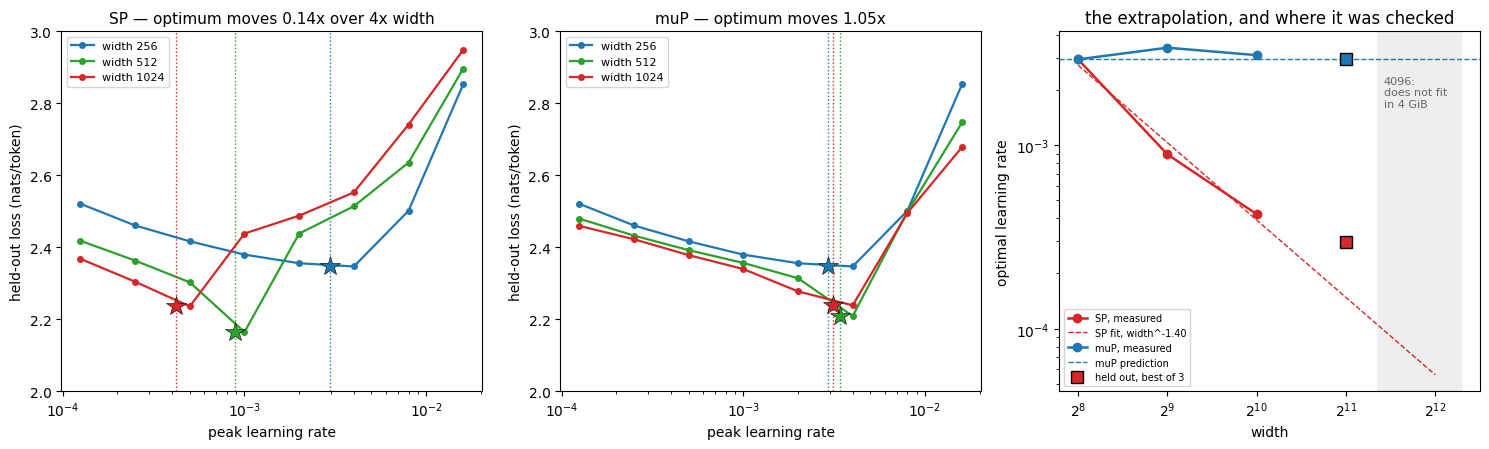

In [33]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4.6))
cols = {256: "#1f77b4", 512: "#2ca02c", 1024: "#d62728", 2048: "#9467bd"}

for i, pz in enumerate(("sp", "mup")):
    for w in SWEEP_WIDTHS:
        ax[i].plot(SWEEP_LRS, sweeps[(pz, w)], "o-", color=cols[w], lw=1.6, ms=4,
                   label=f"width {w}")
        mx = minima[(pz, w)]
        ax[i].axvline(mx, color=cols[w], lw=1.0, ls=":")
        ax[i].plot([mx], [min(sweeps[(pz, w)])], "*", color=cols[w], ms=15,
                   markeredgecolor="k", markeredgewidth=0.4)
    ax[i].set_xscale("log")
    ax[i].set_xlabel("peak learning rate"); ax[i].set_ylabel("held-out loss (nats/token)")
    ax[i].set_ylim(2.0, 3.0)
    ax[i].legend(fontsize=8)
ax[0].set_title(f"SP — optimum moves {sp_shift:.2f}x over 4x width", fontsize=11)
ax[1].set_title(f"muP — optimum moves {mup_shift:.2f}x", fontsize=11)

ws = np.array(SWEEP_WIDTHS + [HELD_W, 4096], dtype=float)
ax[2].plot(SWEEP_WIDTHS, [minima[("sp", w)] for w in SWEEP_WIDTHS], "o-", color="#d62728",
           lw=1.8, label="SP, measured")
ax[2].plot(ws, 2 ** np.polyval(sp_fit, np.log2(ws)), "--", color="#d62728", lw=1.0,
           label=f"SP fit, width^{sp_fit[0]:.2f}")
ax[2].plot(SWEEP_WIDTHS, [minima[("mup", w)] for w in SWEEP_WIDTHS], "o-", color="#1f77b4",
           lw=1.8, label="muP, measured")
ax[2].axhline(mup_pred, color="#1f77b4", ls="--", lw=1.0, label="muP prediction")
ax[2].plot([HELD_W], [held["sp"][0][int(np.argmin(held["sp"][1]))]], "s", color="#d62728",
           ms=9, markeredgecolor="k", label="held out, best of 3")
ax[2].plot([HELD_W], [held["mup"][0][int(np.argmin(held["mup"][1]))]], "s", color="#1f77b4",
           ms=9, markeredgecolor="k")
ax[2].axvspan(2600, 5000, color="#eeeeee")
ax[2].text(2750, mup_pred * 0.55, "4096:\ndoes not fit\nin 4 GiB", fontsize=8, color="#666")
ax[2].set_xscale("log", base=2); ax[2].set_yscale("log")
ax[2].set_xlabel("width"); ax[2].set_ylabel("optimal learning rate")
ax[2].set_title("the extrapolation, and where it was checked")
ax[2].legend(fontsize=7)

fig.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "lr_sweep.png"), dpi=130)
show(fig)

## 6. Tune both sides

> *Almost every optimizer claim that failed to replicate was a well tuned method measured
> against a badly tuned one.*

This is the easiest instruction in the assignment to agree with and the easiest to violate,
because violating it does not feel like cheating — it feels like using the defaults. So
rather than assert the principle, this section commits the error twice, on purpose, with the
honest version of each comparison run immediately afterwards on the same machine, the same
model and the same seeds.

The protocol for "tuned", fixed in advance and applied identically to both sides:

* the **same number of trials** (7) for every arm,
* each arm's grid spaced by a factor of 2 and **positioned so that the winner is interior**
  — an optimum sitting at the edge of a grid means the arm was not tuned, and the code
  checks and says so,
* the same budget, the same schedule, the same three data seeds,
* and a verdict only when the gap clears the noise floor measured in section 0.

In [34]:
rule("6. Comparison one: AdamW against SGD with momentum")

CMP_STEPS_6 = 300
ADAMW_GRID = [2.5e-4, 5e-4, 1e-3, 2e-3, 4e-3, 8e-3, 1.6e-2]
SGD_GRID = [0.0125, 0.025, 0.05, 0.1, 0.2, 0.4, 0.8]


def tuned(grid, label, **kw):
    losses = []
    for lr in grid:
        r = train(steps=CMP_STEPS_6, lr=lr, schedule="cosine", warmup=20, **kw)
        losses.append(r["final_eval"])
        del r
        torch.cuda.empty_cache() if device.type == "cuda" else None
    i = int(np.argmin(losses))
    interior = 0 < i < len(grid) - 1
    print(f"  {label:<22} " + " ".join(f"{v:6.3f}" for v in losses)
          + f"   best {grid[i]:.3g}" + ("" if interior else "   <-- AT THE GRID EDGE"))
    return grid, losses, grid[i], losses[i], interior


adamw_grid, adamw_losses, adamw_lr, adamw_best, adamw_int = tuned(
    ADAMW_GRID, "AdamW", opt_name="adamw")
sgd_grid, sgd_losses, sgd_lr, sgd_best, sgd_int = tuned(
    SGD_GRID, "SGD + momentum 0.9", opt_name="sgdm")
print(f"\n  both optima interior to their grids : {adamw_int and sgd_int}")

# The comparison nobody would publish on purpose, and everybody has run by accident.
sgd_at_adamw_lr = train(steps=CMP_STEPS_6, lr=adamw_lr, schedule="cosine", warmup=20,
                        opt_name="sgdm")["final_eval"]
adamw_at_sgd_lr = train(steps=CMP_STEPS_6, lr=sgd_lr, schedule="cosine", warmup=20,
                        opt_name="adamw")["final_eval"]

print(f"\n{'the comparison':<44} {'AdamW':>9} {'SGD+m':>9} {'gap':>9}")
print("-" * 74)
print(f"{'SGD run at AdamW' + chr(39) + 's learning rate':<44} {adamw_best:>9.4f} "
      f"{sgd_at_adamw_lr:>9.4f} {sgd_at_adamw_lr - adamw_best:>+9.4f}")
print(f"{'AdamW run at SGD' + chr(39) + 's learning rate':<44} {adamw_at_sgd_lr:>9.4f} "
      f"{sgd_best:>9.4f} {sgd_best - adamw_at_sgd_lr:>+9.4f}")
print(f"{'both tuned, 7 trials each':<44} {adamw_best:>9.4f} {sgd_best:>9.4f} "
      f"{sgd_best - adamw_best:>+9.4f}")
print(f"\nthe untuned comparison overstates AdamW's advantage by "
      f"{(sgd_at_adamw_lr - adamw_best) / max(sgd_best - adamw_best, 1e-9):.1f}x.")
print(f"and run the other way round it reverses the result entirely: at SGD's learning rate")
print(f"AdamW {'loses to' if adamw_at_sgd_lr > sgd_best else 'still beats'} SGD.  Either "
      f"direction is available to anyone who")
print(f"only tunes one side, which is why the direction chosen tends to be the flattering "
      f"one.")
print(f"\nthe real gap, {sgd_best - adamw_best:+.4f} nats, is "
      f"{abs(sgd_best - adamw_best) / NOISE_FLOOR:.1f}x the {NOISE_FLOOR:.4f}-nat noise "
      f"floor, so it is a real result:")
print(f"AdamW is genuinely better here -- by much less than the careless comparison says, "
      f"and it\ncost 14 runs rather than 2 to find out.")
record("cmp_steps", CMP_STEPS_6)
record("cmp_adamw_grid", adamw_grid)
record("cmp_adamw_losses", adamw_losses)
record("cmp_sgd_grid", sgd_grid)
record("cmp_sgd_losses", sgd_losses)
record("cmp_adamw_lr", adamw_lr)
record("cmp_sgd_lr", sgd_lr)
record("cmp_adamw_best", adamw_best)
record("cmp_sgd_best", sgd_best)
record("cmp_sgd_at_adamw_lr", sgd_at_adamw_lr)
record("cmp_adamw_at_sgd_lr", adamw_at_sgd_lr)
record("cmp_both_interior", bool(adamw_int and sgd_int))
record("cmp_overstatement",
       (sgd_at_adamw_lr - adamw_best) / max(sgd_best - adamw_best, 1e-9))


6. Comparison one: AdamW against SGD with momentum   [t+19m06s]


  AdamW                   2.411  2.345  2.238  2.111  2.116  2.491  2.777   best 0.002


  SGD + momentum 0.9      2.465  2.435  2.416  2.405  2.400  2.463  2.644   best 0.2

  both optima interior to their grids : True



the comparison                                   AdamW     SGD+m       gap
--------------------------------------------------------------------------
SGD run at AdamW's learning rate                2.1112    2.6359   +0.5246
AdamW run at SGD's learning rate                3.3364    2.3997   -0.9367
both tuned, 7 trials each                       2.1112    2.3997   +0.2885

the untuned comparison overstates AdamW's advantage by 1.8x.
and run the other way round it reverses the result entirely: at SGD's learning rate
AdamW loses to SGD.  Either direction is available to anyone who
only tunes one side, which is why the direction chosen tends to be the flattering one.

the real gap, +0.2885 nats, is 10.2x the 0.0282-nat noise floor, so it is a real result:
AdamW is genuinely better here -- by much less than the careless comparison says, and it
cost 14 runs rather than 2 to find out.


1.8187212768479868

### Comparison two: how to discover an optimizer that does not exist

The first comparison is the obvious failure — SGD at Adam's learning rate is visibly broken
and someone would catch it. The dangerous version is the one where the badly tuned baseline
looks *fine*.

So: a challenger. `AdamW` with `β₂ = 0.95` instead of `0.999` — a real change that real
papers make, shortening the window over which the second moment is averaged from ~1000 steps
to ~20. Tune the challenger over seven learning rates. Run the baseline at `3e-4`, which is
not a strawman: it is the number the lecture says everyone starts from, it is nanoGPT's
default, and it is a perfectly reasonable thing to type.

In [35]:
rule("6b. Comparison two: a challenger that is not one")

b95_grid, b95_losses, b95_lr, b95_best, b95_int = tuned(
    ADAMW_GRID, "AdamW, beta2=0.95", opt_name="adamw", betas=(0.9, 0.95))
DEFAULT_LR = 3e-4
baseline_default = train(steps=CMP_STEPS_6, lr=DEFAULT_LR, schedule="cosine", warmup=20,
                         opt_name="adamw")["final_eval"]

print(f"\n  challenger (beta2=0.95), tuned over 7 learning rates : {b95_best:.4f} "
      f"at lr {b95_lr:.0e}")
print(f"  baseline  (beta2=0.999) at the default lr {DEFAULT_LR:.0e}       : "
      f"{baseline_default:.4f}")
print(f"  baseline  (beta2=0.999), tuned over the same 7          : {adamw_best:.4f} "
      f"at lr {adamw_lr:.0e}")

fake = baseline_default - b95_best
real = adamw_best - b95_best
print(f"\n  THE PAPER I COULD HAVE WRITTEN : 'shortening the second-moment window improves")
print(f"    held-out loss by {fake:.4f} nats' -- {abs(fake) / NOISE_FLOOR:.0f}x the noise "
      f"floor, reproducible on demand,")
print(f"    and false.")
print(f"  THE MEASUREMENT                : {real:+.4f} nats, "
      f"{'inside' if abs(real) < NOISE_FLOOR else 'outside'} the {NOISE_FLOOR:.4f}-nat "
      f"noise floor.")
if abs(real) < NOISE_FLOOR:
    verdict = ("    There is no effect here that this experiment can resolve.  The entire "
               "claimed\n    improvement was the baseline's untuned learning rate.")
elif real < 0:
    verdict = (f"    The claimed improvement does not merely vanish -- IT REVERSES.  With "
               f"both sides\n    tuned, beta2=0.95 is {abs(real):.4f} nats WORSE than the "
               f"baseline it was supposed to beat.\n    The untuned comparison got the "
               f"sign wrong, not just the size.")
else:
    verdict = (f"    There is a real effect in the claimed direction, and it is "
               f"{fake / real:.0f}x smaller than the\n    untuned comparison says.")
print(verdict)
print(f"\n  Nothing about the first claim requires dishonesty.  The baseline ran, it "
      f"converged, its")
print(f"  loss curve looks healthy, and 3e-4 is what the field's own folklore recommends.")
print(f"  The only thing wrong with it is that {adamw_lr:.0e} was "
      f"{adamw_lr / DEFAULT_LR:.0f}x better and nobody looked.")
record("cmp_b95_grid", b95_grid)
record("cmp_b95_losses", b95_losses)
record("cmp_b95_lr", b95_lr)
record("cmp_b95_best", b95_best)
record("cmp_default_lr", DEFAULT_LR)
record("cmp_baseline_default", baseline_default)
record("cmp_fake_gap", fake)
record("cmp_real_gap", real)
record("cmp_real_inside_floor", bool(abs(real) < NOISE_FLOOR))


6b. Comparison two: a challenger that is not one   [t+19m55s]


  AdamW, beta2=0.95       2.417  2.359  2.283  2.142  2.159  2.481  2.664   best 0.002



  challenger (beta2=0.95), tuned over 7 learning rates : 2.1417 at lr 2e-03
  baseline  (beta2=0.999) at the default lr 3e-04       : 2.3899
  baseline  (beta2=0.999), tuned over the same 7          : 2.1112 at lr 2e-03

  THE PAPER I COULD HAVE WRITTEN : 'shortening the second-moment window improves
    held-out loss by 0.2482 nats' -- 9x the noise floor, reproducible on demand,
    and false.
  THE MEASUREMENT                : -0.0305 nats, outside the 0.0282-nat noise floor.
    The claimed improvement does not merely vanish -- IT REVERSES.  With both sides
    tuned, beta2=0.95 is 0.0305 nats WORSE than the baseline it was supposed to beat.
    The untuned comparison got the sign wrong, not just the size.

  Nothing about the first claim requires dishonesty.  The baseline ran, it converged, its
  loss curve looks healthy, and 3e-4 is what the field's own folklore recommends.
  The only thing wrong with it is that 2e-03 was 7x better and nobody looked.


False

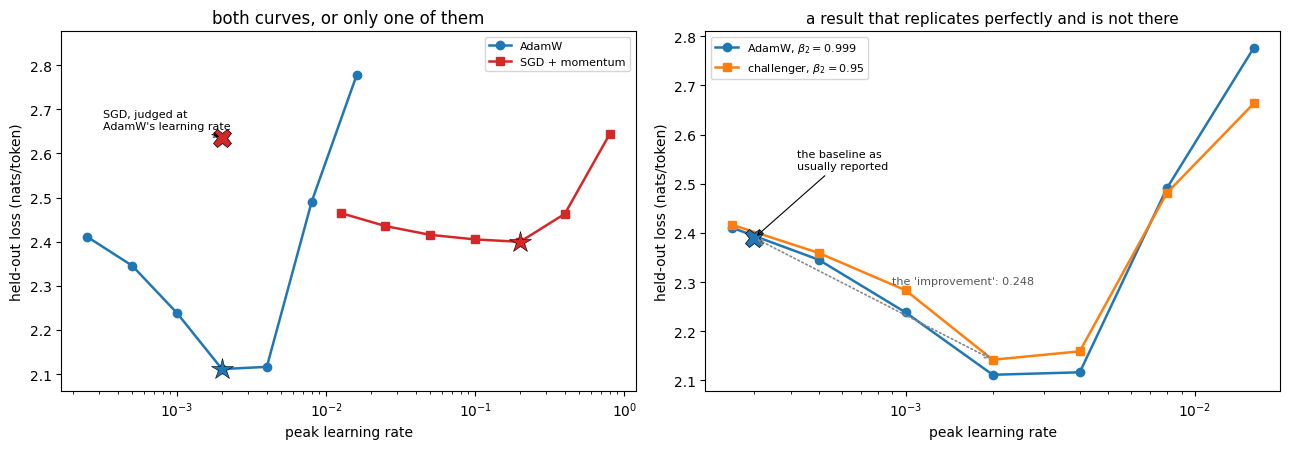

In [36]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.6))

ax[0].plot(adamw_grid, adamw_losses, "o-", lw=1.8, color="#1f77b4", label="AdamW")
ax[0].plot(sgd_grid, sgd_losses, "s-", lw=1.8, color="#d62728", label="SGD + momentum")
ax[0].plot([adamw_lr], [sgd_at_adamw_lr], "X", ms=13, color="#d62728",
           markeredgecolor="k", markeredgewidth=0.5)
ax[0].annotate("SGD, judged at\nAdamW's learning rate", xy=(adamw_lr, sgd_at_adamw_lr),
               xytext=(adamw_lr * 0.16, sgd_at_adamw_lr + 0.02), fontsize=8,
               arrowprops=dict(arrowstyle="->", lw=0.8))
ax[0].plot([adamw_lr], [adamw_best], "*", ms=16, color="#1f77b4", markeredgecolor="k",
           markeredgewidth=0.4)
ax[0].plot([sgd_lr], [sgd_best], "*", ms=16, color="#d62728", markeredgecolor="k",
           markeredgewidth=0.4)
ax[0].set_xscale("log"); ax[0].set_xlabel("peak learning rate")
ax[0].set_ylabel("held-out loss (nats/token)")
ax[0].set_title("both curves, or only one of them")
_lo = min(adamw_losses + sgd_losses)
ax[0].set_ylim(_lo - 0.05, min(max(adamw_losses + sgd_losses + [sgd_at_adamw_lr]),
                               _lo + 1.2) + 0.1)
ax[0].legend(fontsize=8)

ax[1].plot(ADAMW_GRID, adamw_losses, "o-", lw=1.8, color="#1f77b4",
           label=r"AdamW, $\beta_2=0.999$")
ax[1].plot(ADAMW_GRID, b95_losses, "s-", lw=1.8, color="#ff7f0e",
           label=r"challenger, $\beta_2=0.95$")
ax[1].plot([DEFAULT_LR], [baseline_default], "X", ms=13, color="#1f77b4",
           markeredgecolor="k", markeredgewidth=0.5)
ax[1].annotate("the baseline as\nusually reported", xy=(DEFAULT_LR, baseline_default),
               xytext=(DEFAULT_LR * 1.4, baseline_default + 0.14), fontsize=8,
               arrowprops=dict(arrowstyle="->", lw=0.8))
ax[1].annotate("", xy=(b95_lr, b95_best), xytext=(DEFAULT_LR, baseline_default),
               arrowprops=dict(arrowstyle="<->", lw=1.2, color="#888", ls=":"))
ax[1].text(9e-4, (baseline_default + b95_best) / 2 + 0.03,
           f"the 'improvement': {fake:.3f}", fontsize=8, color="#555")
ax[1].set_xscale("log"); ax[1].set_xlabel("peak learning rate")
ax[1].set_ylabel("held-out loss (nats/token)")
ax[1].set_title("a result that replicates perfectly and is not there", fontsize=11)
ax[1].legend(fontsize=8)

fig.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "tuning.png"), dpi=130)
show(fig)

## What this notebook spent its GPU time on

In [37]:
rule("Done")
ELAPSED = time.time() - T_START
record("elapsed_s", round(ELAPSED, 1))
record("n_results_keys", len(RESULTS) + 1)
with open(os.path.join(OUT_DIR, "results.json"), "w", encoding="utf-8") as f:
    json.dump(RESULTS, f, indent=1, default=float, ensure_ascii=False)
print(f"wrote results/results.json  ({len(RESULTS)} recorded values)")
print(f"figures: bias_correction.png, update_ratio.png, schedules.png, lr_sweep.png, "
      f"tuning.png")
print(f"elapsed: {ELAPSED / 60:.1f} minutes on {RESULTS.get('gpu') or 'CPU'}")
print(f"""
the six answers, in one place
----------------------------
1. Adam by hand reproduces torch's m, v and w to
   {RESULTS['hand_vs_torch_worst_digits']:.0f} digits over five gradients; the first step is
   exactly lr regardless of the gradient, and a {RESULTS['outlier_g_ratio']:.0f}x gradient
   spike buys only a {RESULTS['outlier_step_ratio']:.2f}x step.
2. Bias correction is one scalar per step, worst at step {RESULTS['bc_worst_t']}
   ({RESULTS['bc_worst_factor']:.2f}x too large without it), within 1% of 1 only after
   {RESULTS['bc_t_within_1pct']:,} steps.  The step converges; the model does not -- the gap
   never came back inside the noise floor in {RESULTS['bc_steps']} steps without warmup.  A
   {RESULTS['bc_warmup_len']}-step warmup shrinks it {RESULTS['bc_wu_gap_shrink']:.1f}x, to
   the edge of what this experiment can resolve.
3. The update-to-weight ratio spans {RESULTS['ratio_spread']:.0f}x across the matrices and
   decays {RESULTS['ratio_decay']:.2f}x after warmup at a CONSTANT learning rate; warmup is
   the dominant driver of it only up to step
   {RESULTS['ratio_warmup_dominant_until']}, and contributes exactly nothing after step
   {RESULTS['ratio_warmup']}.
4. Stopped at {RESULTS['sched_stop_at']}: cosine
   {np.mean(RESULTS['sched_arm_at_200']['cosine, budget 300']):.4f}, WSD
   {np.mean(RESULTS['sched_arm_at_200']['WSD, budget 300']):.4f}.  Re-planned for the budget
   actually used, WSD reaches
   {np.mean(RESULTS['sched_arm_at_200']['WSD cooled into 200']):.4f}.
5. The optimum moves {RESULTS['sweep_sp_shift']:.2f}x over 4x width under SP and
   {RESULTS['sweep_mup_shift']:.2f}x under muP; at width 4096 I would use
   {RESULTS['final_lr_4096']:.1e} under muP.
6. Tuning only one side overstated AdamW's margin over SGD by
   {RESULTS['cmp_overstatement']:.1f}x -- and reversed it outright when run the other way
   round.  It also manufactured a {RESULTS['cmp_fake_gap']:.4f}-nat "improvement" from a
   change whose real effect is {RESULTS['cmp_real_gap']:+.4f}{' -- the opposite direction' if RESULTS['cmp_real_gap'] < 0 else ''}.
""")


Done   [t+20m21s]
wrote results/results.json  (188 recorded values)
figures: bias_correction.png, update_ratio.png, schedules.png, lr_sweep.png, tuning.png
elapsed: 20.4 minutes on NVIDIA GeForce RTX 3050 Laptop GPU

the six answers, in one place
----------------------------
1. Adam by hand reproduces torch's m, v and w to
   16 digits over five gradients; the first step is
   exactly lr regardless of the gradient, and a 30x gradient
   spike buys only a 1.10x step.
2. Bias correction is one scalar per step, worst at step 12
   (6.57x too large without it), within 1% of 1 only after
   3,916 steps.  The step converges; the model does not -- the gap
   never came back inside the noise floor in 1200 steps without warmup.  A
   100-step warmup shrinks it 5.4x, to
   the edge of what this experiment can resolve.
3. The update-to-weight ratio spans 3x across the matrices and
   decays 0.61x after warmup at a CONSTANT learning rate; warmup is
   the dominant driver of it only up to step
   